# **Eksperimen 1 : baseline ML**

In [1]:
import numpy as np
import pandas as pd
import json
import joblib
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, 
                             precision_recall_curve, auc)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

# checkpoint setup
base_path = Path.cwd().parent / "results"
base_path = base_path.resolve()
print(f"Base path: {base_path}")

Base path: D:\Projek pribadi\scholarship,exchange,pelatihan\Rakamin-VIX-Intership-IDX\credit_risk_v2\notebooks\results


In [2]:
class CheckpointManager:
    """Save/load experiment results."""
    
    DIRS = {
        'preprocessing': '01_preprocessing',
        'exp1_no_strat_baseline': '02_experiments/exp1_no_strat_baseline',  # FIXED
        'exp1_strat_baseline': '02_experiments/exp1_strat_baseline',        # FIXED
        'exp2_smote': '02_experiments/exp2_strat_smote',
        'exp2_tuned': '02_experiments/exp2_strat_smote_tuned',
        'exp2_strat_smote': '02_experiments/exp2_strat_smote',          # ← TAMBAHKAN INI
        'exp2_strat_smote_tuned': '02_experiments/exp2_strat_smote_tuned', # ← TAMBAHKAN INI
        'final': '03_final_summary'
    }
    
    def __init__(self, base_path):
        self.base_path = Path(base_path)
        for d in self.DIRS.values():
            (self.base_path / d).mkdir(parents=True, exist_ok=True)
    
    def _path(self, section, filename=None):
        p = self.base_path / self.DIRS[section]
        return p / filename if filename else p
    
    def exists(self, section, filename):
        return self._path(section, filename).exists()
    
    def save_df(self, df, section, filename):
        df.to_parquet(self._path(section, filename), index=False)
    
    def load_df(self, section, filename):
        return pd.read_parquet(self._path(section, filename))
    
    def save_model(self, model, section, filename):
        joblib.dump(model, self._path(section, filename))
    
    def load_model(self, section, filename):
        return joblib.load(self._path(section, filename))
    
    def save_json(self, data, section, filename):
        with open(self._path(section, filename), 'w') as f:
            json.dump(data, f, indent=2, default=str)
    
    def load_json(self, section, filename):
        with open(self._path(section, filename)) as f:
            return json.load(f)

checkpoint = CheckpointManager(base_path)

# 2. Load Dataset

In [3]:
#path Data
data_path = Path("D:/Projek pribadi/scholarship,exchange,pelatihan/Rakamin-VIX-Intership-IDX/Dataset/raw/loan_data_2007_2014.csv")
df_raw = pd.read_csv(data_path)

# Quick view
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (466285, 75)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Quick Analysis

In [4]:
# Status
df_raw['loan_status'].value_counts()


loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [5]:
# Exclude 'Current' & 'In Grace Period' (ongoing loans)
df_model = df_raw[~df_raw['loan_status'].isin(['Current', 'In Grace Period'])].copy()

# Define Good / Bad Loan
good_loans = ['Fully Paid', 'Does not meet credit policy. Status:Fully Paid']
bad_loans = ['Charged Off', 'Default', 'Does not meet credit policy. Status:Charged Off',
             'Late (31-120 days)', 'Late (16-30 days)']

In [6]:
# Create target column: 1 = Good, 0 = Bad
df_model['target'] = df_model['loan_status'].apply(lambda x: 1 if x in good_loans else 0)

# Save CP1: Clean data
checkpoint.save_df(df_model, "preprocessing", "CP1_clean_data.parquet")

In [7]:
# Quick check
print(df_model['target'].value_counts())

target
1    184739
0     54174
Name: count, dtype: int64


In [8]:
# Feature selection
features_numeric_safe = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc'
]

# grade is redundant with sub_grade, so we drop it
features_categorical_safe = ['sub_grade', 'term', 'home_ownership', 'verification_status', 'purpose']
selected_features_safe = features_numeric_safe + features_categorical_safe

checkpoint.save_json({
    'numeric': features_numeric_safe,
    'categorical': features_categorical_safe
}, 'preprocessing', 'features.json')

In [9]:
# Subset dataframe dengan fitur terpilih + target
df_model_clean = df_model[selected_features_safe + ['target']].copy()


In [10]:
# Cek missing values
missing_summary = df_model_clean.isnull().sum().sort_values(ascending=False)
print("Missing values per feature:\n", missing_summary)

Missing values per feature:
 revol_util             232
delinq_2yrs             29
inq_last_6mths          29
open_acc                29
pub_rec                 29
total_acc               29
annual_inc               4
loan_amnt                0
term                     0
purpose                  0
verification_status      0
home_ownership           0
revol_bal                0
sub_grade                0
int_rate                 0
dti                      0
target                   0
dtype: int64


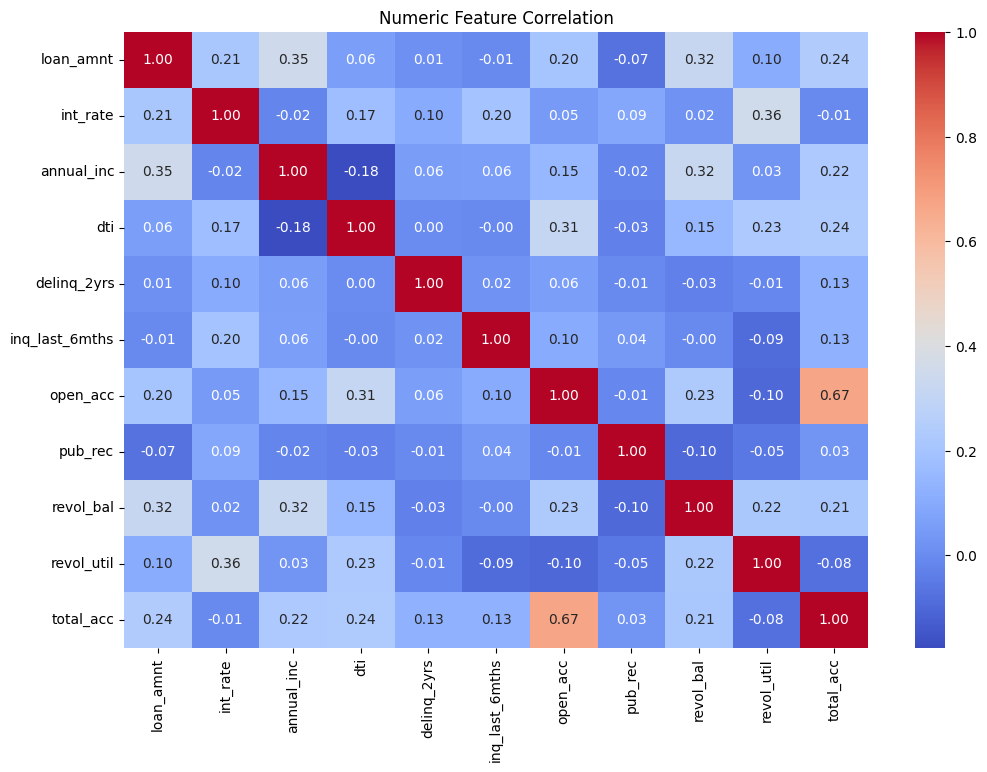

In [11]:
# Korelasi numerik
plt.figure(figsize=(12,8))
sns.heatmap(df_model_clean[features_numeric_safe].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

In [12]:
corr_with_target = df_model_clean[features_numeric_safe + ['target']].corr()['target']
corr_with_target = corr_with_target.drop('target').sort_values(key=abs, ascending=False)

print("Korelasi fitur numerik dengan TARGET:")
print(corr_with_target)


Korelasi fitur numerik dengan TARGET:
int_rate         -0.252715
dti              -0.120337
inq_last_6mths   -0.106244
revol_util       -0.094879
loan_amnt        -0.062226
annual_inc        0.059685
delinq_2yrs      -0.030365
total_acc         0.024806
open_acc         -0.024455
pub_rec          -0.015069
revol_bal        -0.010642
Name: target, dtype: float64


### Analisis Korelasi dengan TARGET (Good/Bad Loan)



#### **Fitur dengan Korelasi Negatif**
> **"Makin tinggi nilainya, makin besar kemungkinan menjadi BAD loan."**

1. **`int_rate` (-0.2527)**
   - **Interpretasi:** Semakin tinggi **interest rate (bunga)**, semakin **besar kemungkinan pinjaman itu jadi BAD**.
   - **Pengaruh:** Cukup besar karena lebih dari -0.25. Bisa jadi indikator penting untuk prediksi pinjaman buruk.

2. **`dti` (-0.1203)**
   - **Interpretasi:** Semakin besar **debt-to-income ratio (rasio utang terhadap pendapatan)**, semakin **besar kemungkinan pinjaman itu BAD**.
   - **Pengaruh:** Pengaruhnya lebih kecil dari interest rate, tapi masih cukup relevan untuk evaluasi risiko.

3. **`inq_last_6mths` (-0.1062)**
   - **Interpretasi:** Semakin banyak **kredit inquiries dalam 6 bulan terakhir**, semakin besar kemungkinan pinjaman menjadi BAD.
   - **Pengaruh:** Cukup kecil, tapi tetap bisa menunjukkan orang yang **sering mengajukan kredit** cenderung lebih berisiko.

4. **`revol_util` (-0.0949)**
   - **Interpretasi:** **Pemakaian kredit** yang lebih tinggi (semakin dekat ke 100%) menunjukkan **kemungkinan lebih besar untuk BAD loan**.
   - **Pengaruh:** Tidak besar, tapi tetap membantu menunjukkan orang yang memanfaatkan hampir seluruh limit kredit.

5. **`loan_amnt` (-0.0622)**
   - **Interpretasi:** Jumlah pinjaman yang lebih tinggi, cenderung **lebih besar risikonya** untuk menjadi BAD loan.
   - **Pengaruh:** Pengaruhnya cukup kecil. Bisa jadi menunjukkan pola pinjaman besar lebih berisiko, tetapi efeknya tidak terlalu kuat.

---

### **Fitur dengan Korelasi Positif**
> **"Makin tinggi nilainya, makin besar kemungkinan menjadi GOOD loan."**

1. **`annual_inc` (0.0597)**
   - **Interpretasi:** Semakin tinggi **pendapatan tahunan**, semakin **besar kemungkinan pinjaman itu GOOD**.
   - **Pengaruh:** Sangat kecil, namun tetap mencerminkan bahwa orang dengan pendapatan tinggi lebih mungkin melunasi pinjaman dengan baik.

---

### **Fitur yang Hampir Tidak Berpengaruh**

* **`delinq_2yrs` (-0.0304)** → Pengaruhnya **sangat kecil**.
* **`total_acc` (0.0248)** → Hanya sedikit pengaruh, artinya tidak ada korelasi yang jelas dengan target.
* **`open_acc` (-0.0245)** → Sama seperti `total_acc`, tidak ada hubungan yang kuat.
* **`pub_rec` (-0.0151)** → Sangat kecil, berarti tidak memberikan banyak informasi.
* **`revol_bal` (-0.0106)** → Tidak ada pengaruh yang signifikan terhadap target.

---

## **Apa yang bisa disimpulkan?**

1. **`int_rate` dan `dti`** memiliki korelasi **terkuat negatif** dengan target.
   - Ini menunjukkan bahwa pinjaman dengan bunga tinggi dan utang lebih besar cenderung berisiko lebih tinggi.

2. **`annual_inc`** meskipun **positif**, pengaruhnya **sangat kecil**.
   - Artinya, **pendapatan tinggi** tidak terlalu berpengaruh dalam menentukan apakah pinjaman akan good atau bad (berbeda dengan yang kita kira).

3. **Fitur lainnya** (seperti `loan_amnt`, `inq_last_6mths`) berpengaruh, tetapi **pengaruhnya kecil**.

4. Fitur seperti **`revol_bal`** dan **`pub_rec`** **hampir tidak ada pengaruhnya** terhadap status loan.

---

##  **Langkah Selanjutnya:**

* **Pilih fitur yang paling berpengaruh**:
  Berdasarkan korelasi ini, fitur seperti **`int_rate`**, **`dti`**, dan mungkin **`annual_inc`** bisa jadi **utama** untuk model prediksi.

* **Data preprocessing** (misal: scaling fitur numerik, encoding fitur kategorikal) sebelum masuk ke modeling.

* **Modeling**: Cobalah dengan **Logistic Regression, Decision Tree, atau Random Forest**, dan lihat mana yang memberikan hasil terbaik

# 4. Splitting & Preprocessing

In [13]:
#  Preprocessing Pipeline

# Import yang dibutuhkan
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric Pipeline (imputasi dengan median, scaling)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputasi untuk fitur numerik
    ('scaler', StandardScaler())  # Scaling fitur numerik
])

# Categorical Pipeline (imputasi dengan mode, one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputasi dengan modus
    ('onehot', OneHotEncoder(drop='first'))  # One-hot encoding
])

# Gabungkan keduanya dalam ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numeric_safe),  # Apply to numeric features
        ('cat', categorical_transformer, features_categorical_safe)  # Apply to categorical features
    ])

# Save CP3: Preprocessor
checkpoint.save_model(preprocessor, "preprocessing", "CP3_preprocessor.joblib")

# Tampilkan hasil transformasi
print("Preprocessor Setup Sukses!")

Preprocessor Setup Sukses!


In [14]:
# Quick load - skip preprocessing if already done
config = checkpoint.load_json('preprocessing', 'features.json')
features_numeric = config['numeric']
features_categorical = config['categorical']
df_model_clean = checkpoint.load_df('preprocessing', 'CP1_clean_data.parquet')

## withhout stratify

In [15]:
#  Split Data into Train & Test (80/20 split)
X = df_model_clean.drop(['target'], axis=1)
y = df_model_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Membuat Model Pipeline

# Logistic Regression Pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('classifier', LogisticRegression(random_state=42))  # Logistic Regression classifier
])

# Decision Tree Pipeline
dtree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('classifier', DecisionTreeClassifier(random_state=42))  # Decision Tree classifier
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))  # Random Forest classifier
])


## with Stratify

In [17]:
# Split data with stratify
X_stratify = df_model_clean.drop('target', axis=1)
y_stratify = df_model_clean['target']
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_stratify, y_stratify, test_size=0.2, stratify=y_stratify, random_state=42
)


In [18]:
# Logistic Regression Pipeline dengan stratify
logreg_pipeline_strat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


In [19]:
# Random Forest Pipeline dengan stratify
rf_pipeline_strat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [20]:
# Decision Tree Pipeline dengan stratify
dtree_pipeline_strat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])


# 5. Training 



## without stratify

In [21]:
# Logistic Regression
logreg_pipeline.fit(X_train, y_train)
logreg_score = logreg_pipeline.score(X_test, y_test)
print(f"Logistic Regression Accuracy: {logreg_score:.4f}")

# Save CP4: Logistic Regression model
checkpoint.save_model(logreg_pipeline, "exp1_no_strat_baseline", "CP4_no_strat_logreg.joblib")

# Calculate and save metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = logreg_pipeline.predict(X_test)
y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),  # BUG FIX: y_test (bukan y_test_strat)
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_no_strat_baseline", "CP4_no_strat_logreg_metrics.json")

Logistic Regression Accuracy: 0.7787


In [22]:
# Decision Tree
dtree_pipeline.fit(X_train, y_train)
dtree_score = dtree_pipeline.score(X_test, y_test)
print(f"Decision Tree Accuracy: {dtree_score:.4f}")

# Save CP4: Decision Tree model
checkpoint.save_model(dtree_pipeline, "exp1_no_strat_baseline", "CP4_no_strat_dt.joblib")

# Calculate and save metrics
y_pred = dtree_pipeline.predict(X_test)
y_pred_proba = dtree_pipeline.predict_proba(X_test)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_no_strat_baseline", "CP4_no_strat_dt_metrics.json")

Decision Tree Accuracy: 0.6824


In [23]:
# Random Forest
rf_pipeline.fit(X_train, y_train)
rf_score = rf_pipeline.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_score:.4f}")

# Save CP4: Random Forest model
checkpoint.save_model(rf_pipeline, "exp1_no_strat_baseline", "CP4_no_strat_rf.joblib")

# Calculate and save metrics
y_pred = rf_pipeline.predict(X_test)
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_no_strat_baseline", "CP4_no_strat_rf_metrics.json")

Random Forest Accuracy: 0.7799


## with stratify

In [24]:
# Logistic Regression
logreg_pipeline.fit(X_train_strat, y_train_strat)
logreg_score = logreg_pipeline.score(X_test_strat, y_test_strat)
print(f"Logistic Regression Accuracy (Stratified): {logreg_score:.4f}")

# Save CP5: Logistic Regression model with stratify
checkpoint.save_model(logreg_pipeline, "exp1_strat_baseline", "CP5_strat_logreg.joblib")

# Calculate and save metrics
y_pred = logreg_pipeline.predict(X_test_strat)
y_pred_proba = logreg_pipeline.predict_proba(X_test_strat)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test_strat, y_pred),
    'precision': precision_score(y_test_strat, y_pred, zero_division=0),
    'recall': recall_score(y_test_strat, y_pred, zero_division=0),
    'f1': f1_score(y_test_strat, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_strat, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_strat_baseline", "CP5_strat_logreg_metrics.json")

Logistic Regression Accuracy (Stratified): 0.7793


In [25]:
# Decision Tree
dtree_pipeline.fit(X_train_strat, y_train_strat)
dtree_score = dtree_pipeline.score(X_test_strat, y_test_strat)
print(f"Decision Tree Accuracy (Stratified): {dtree_score:.4f}")

# Save CP5: Decision Tree model with stratify
checkpoint.save_model(dtree_pipeline, "exp1_strat_baseline", "CP5_strat_dt.joblib")

# Calculate and save metrics
y_pred = dtree_pipeline.predict(X_test_strat)
y_pred_proba = dtree_pipeline.predict_proba(X_test_strat)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test_strat, y_pred),
    'precision': precision_score(y_test_strat, y_pred, zero_division=0),
    'recall': recall_score(y_test_strat, y_pred, zero_division=0),
    'f1': f1_score(y_test_strat, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_strat, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_strat_baseline", "CP5_strat_dt_metrics.json")

Decision Tree Accuracy (Stratified): 0.6850


In [26]:
# Random Forest
rf_pipeline.fit(X_train_strat, y_train_strat)
rf_score = rf_pipeline.score(X_test_strat, y_test_strat)
print(f"Random Forest Accuracy (Stratified): {rf_score:.4f}")

# Save CP5: Random Forest model with stratify
checkpoint.save_model(rf_pipeline, "exp1_strat_baseline", "CP5_strat_rf.joblib")

# Calculate and save metrics
y_pred = rf_pipeline.predict(X_test_strat)
y_pred_proba = rf_pipeline.predict_proba(X_test_strat)[:, 1]
metrics = {
    'accuracy': accuracy_score(y_test_strat, y_pred),
    'precision': precision_score(y_test_strat, y_pred, zero_division=0),
    'recall': recall_score(y_test_strat, y_pred, zero_division=0),
    'f1': f1_score(y_test_strat, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_strat, y_pred_proba)
}
checkpoint.save_json(metrics, "exp1_strat_baseline", "CP5_strat_rf_metrics.json")

Random Forest Accuracy (Stratified): 0.7823


# 6. Deep Evaluation

In [27]:
from sklearn.metrics import confusion_matrix

# Fungsi untuk menampilkan Confusion Matrix
def plot_confusion_matrix(y_test_strat, y_pred):
    cm = confusion_matrix(y_test_strat, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Penjelasan
    print("\nPenjelasan Confusion Matrix:")
    print(f"True Positives (TP): {cm[1, 1]}")  # Kelas 1 yang benar-benar diprediksi 1
    print(f"True Negatives (TN): {cm[0, 0]}")  # Kelas 0 yang benar-benar diprediksi 0
    print(f"False Positives (FP): {cm[0, 1]}") # Kelas 0 yang salah diprediksi 1
    print(f"False Negatives (FN): {cm[1, 0]}") # Kelas 1 yang salah diprediksi 0


In [28]:
from sklearn.metrics import classification_report

# Fungsi untuk menampilkan Classification Report
def plot_classification_report(y_test_strat, y_pred):
    print("\nClassification Report:")
    cr = classification_report(y_test_strat, y_pred)
    print(cr)


In [29]:
from sklearn.metrics import roc_auc_score

# Fungsi untuk menampilkan ROC-AUC Score
def plot_roc_auc_score(y_test_strat, y_pred_prob):
    roc_auc = roc_auc_score(y_test_strat, y_pred_prob)
    print(f"\nROC-AUC Score: {roc_auc:.4f}")


In [30]:
# Fungsi untuk menghitung dan menampilkan Gini Index
def plot_gini_index(roc_auc):
    gini = 2 * roc_auc - 1
    print(f"\nGini Index: {gini:.4f}")


In [31]:
from sklearn.metrics import roc_curve

# Fungsi untuk menghitung dan menampilkan KS Statistic
def plot_ks_statistic(y_test_strat, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y_test_strat, y_pred_prob)
    ks_stat = max(tpr - fpr)  # KS statistic is the maximum difference between TPR and FPR
    print(f"\nKS Statistic: {ks_stat:.4f}")


In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Fungsi untuk menampilkan Precision, Recall, dan F1-Score
def plot_precision_recall_f1(y_test_strat, y_pred):
    precision = precision_score(y_test_strat, y_pred)
    recall = recall_score(y_test_strat, y_pred)
    f1 = f1_score(y_test_strat, y_pred)
    
    print("\nPrecision, Recall, F1-Score:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


In [33]:
def evaluate_model(model, X_test, y_test, name=''):
    """Evaluate and return metrics + plots."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'gini': 2 * roc_auc_score(y_test, y_proba) - 1
    }
    
    print(f"{name}: ACC={metrics['accuracy']:.4f}, AUC={metrics['roc_auc']:.4f}")
    
    # plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0,0],
               xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    axes[0,0].set_title('Confusion Matrix')
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0,1].plot(fpr, tpr, label=f"AUC={metrics['roc_auc']:.3f}")
    axes[0,1].plot([0,1], [0,1], 'k--')
    axes[0,1].set_title('ROC Curve')
    axes[0,1].legend()
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[1,0].plot(recall, precision)
    axes[1,0].set_title('PR Curve')
    
    # metrics bar
    values = [metrics['accuracy'], metrics['precision'], metrics['recall'],
              metrics['f1'], metrics['roc_auc'], metrics['gini']]
    colors = ['#2ecc71' if v > 0.7 else '#e74c3c' for v in values]
    axes[1,1].barh(['ACC', 'Prec', 'Rec', 'F1', 'AUC', 'Gini'], values, color=colors)
    axes[1,1].set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    return metrics

In [64]:
def plot_all_experiments_comparison(results):
    """Compare all experiments."""
    # flatten
    rows = []
    for exp, models in results.items():
        for model, metrics in models.items():
            rows.append({'exp': exp, 'model': model.upper(), **metrics})
    df = pd.DataFrame(rows)
    
    # labels
    labels = {'exp1_no_strat': 'No Strat', 'exp1_strat': 'Strat', 
              'exp2_smote': 'SMOTE', 'exp2_tuned': 'SMOTE+Tuned'}
    df['label'] = df['exp'].map(labels)
    
    # plot
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for idx, metric in enumerate(['accuracy', 'roc_auc', 'recall']):
        df.pivot(index='label', columns='model', values=metric).plot(
            kind='bar', ax=axes[0, idx], color=['#3498db', '#e74c3c', '#2ecc71'])
        axes[0, idx].set_title(metric.upper())
        axes[0, idx].set_ylim(0, 1)
    
    # heatmap
    hm = df.set_index(['label', 'model'])[['accuracy','precision','recall','f1','roc_auc']]
    sns.heatmap(hm.sort_index(level=0, ascending=False), annot=True, fmt='.2f', 
                cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1,0])
    
    # best model text
    axes[1,1].axis('off')
    best = df.loc[df['roc_auc'].idxmax()]
    axes[1,1].text(0.1, 0.5, f"Best: {best['model']} ({best['label']})\nAUC: {best['roc_auc']:.4f}")
    
    axes[1,2].axis('off')
    plt.tight_layout()
    plt.show()
    
    return df

In [35]:
from sklearn.metrics import average_precision_score

# Fungsi untuk menampilkan AUC-PR (Precision-Recall AUC)
def plot_auc_pr(y_test_strat, y_pred_prob):
    auc_pr = average_precision_score(y_test_strat, y_pred_prob)
    print(f"\nAUC-PR: {auc_pr:.4f}")


In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Fungsi untuk plotting ROC Curve
def plot_roc_curve(y_test_strat, y_pred_prob, roc_auc):
    print("\nPlotting ROC Curve...")
    fpr, tpr, _ = roc_curve(y_test_strat, y_pred_prob)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()


In [37]:
def evaluate_model(pipeline, X_test_strat, y_test_strat):
    # Prediksi
    y_pred = pipeline.predict(X_test_strat)
    y_pred_prob = pipeline.predict_proba(X_test_strat)[:, 1]  # Ambil probabilitas untuk class 1 (Good loan)

    # 1. Confusion Matrix
    plot_confusion_matrix(y_test_strat, y_pred)

    # 2. Classification Report
    plot_classification_report(y_test_strat, y_pred)

    # 3. ROC-AUC Score
    plot_roc_auc_score(y_test_strat, y_pred_prob)

    # 4. Gini Index
    plot_gini_index(roc_auc_score(y_test_strat, y_pred_prob))

    # 5. KS Statistic
    plot_ks_statistic(y_test_strat, y_pred_prob)

    # 6. Precision, Recall, F1-Score
    plot_precision_recall_f1(y_test_strat, y_pred)

    # 7. AUC-PR
    plot_auc_pr(y_test_strat, y_pred_prob)

    # 8. Plot ROC Curve
    plot_roc_curve(y_test_strat, y_pred_prob, roc_auc_score(y_test_strat, y_pred_prob))



================= Logistic Regression Evaluation ==================

Confusion Matrix:
[[ 1057  9778]
 [  770 36178]]

Penjelasan Confusion Matrix:
True Positives (TP): 36178
True Negatives (TN): 1057
False Positives (FP): 9778
False Negatives (FN): 770

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.10      0.17     10835
           1       0.79      0.98      0.87     36948

    accuracy                           0.78     47783
   macro avg       0.68      0.54      0.52     47783
weighted avg       0.74      0.78      0.71     47783


ROC-AUC Score: 0.7085

Gini Index: 0.4169

KS Statistic: 0.3055

Precision, Recall, F1-Score:
Precision: 0.7872
Recall: 0.9792
F1 Score: 0.8728

AUC-PR: 0.8832

Plotting ROC Curve...


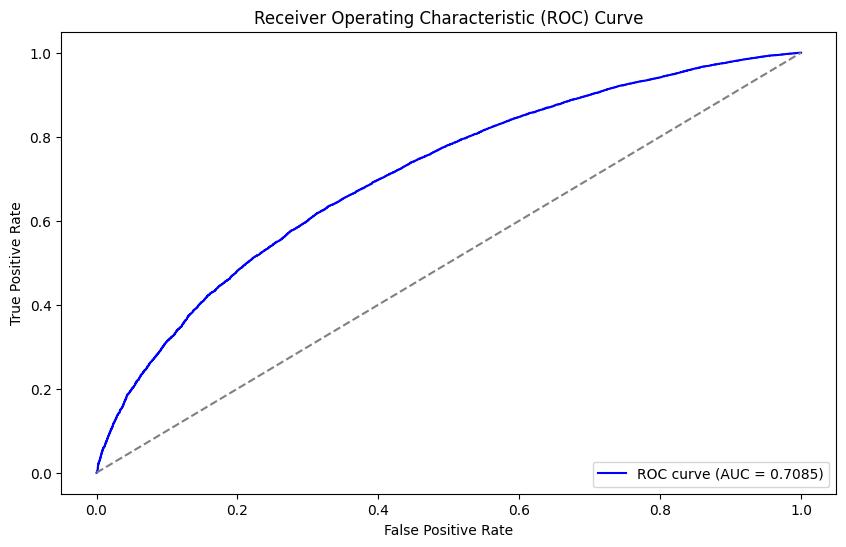


================= Decision Tree Evaluation ==================

Confusion Matrix:
[[ 3664  7171]
 [ 7883 29065]]

Penjelasan Confusion Matrix:
True Positives (TP): 29065
True Negatives (TN): 3664
False Positives (FP): 7171
False Negatives (FN): 7883

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.34      0.33     10835
           1       0.80      0.79      0.79     36948

    accuracy                           0.68     47783
   macro avg       0.56      0.56      0.56     47783
weighted avg       0.69      0.68      0.69     47783


ROC-AUC Score: 0.5624

Gini Index: 0.1248

KS Statistic: 0.1248

Precision, Recall, F1-Score:
Precision: 0.8021
Recall: 0.7866
F1 Score: 0.7943

AUC-PR: 0.7959

Plotting ROC Curve...


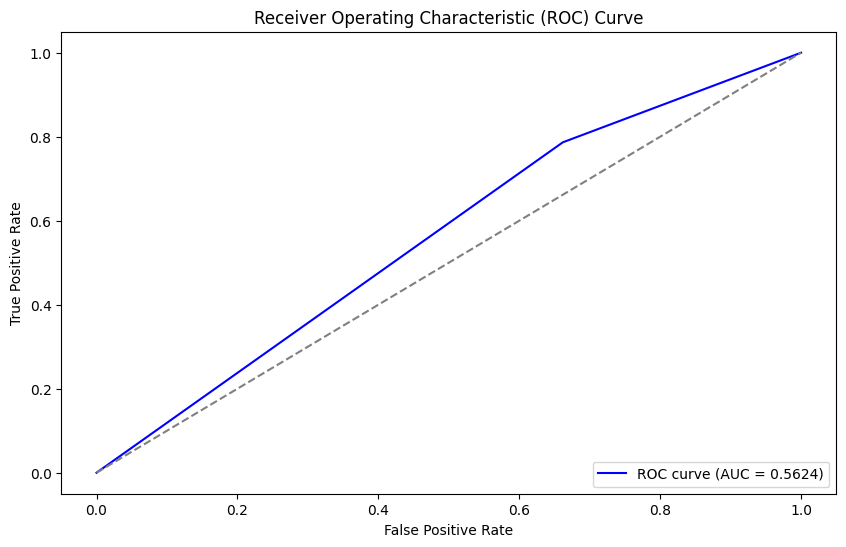


================= Random Forest Evaluation ==================

Confusion Matrix:
[[ 1453  9382]
 [ 1019 35929]]

Penjelasan Confusion Matrix:
True Positives (TP): 35929
True Negatives (TN): 1453
False Positives (FP): 9382
False Negatives (FN): 1019

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.13      0.22     10835
           1       0.79      0.97      0.87     36948

    accuracy                           0.78     47783
   macro avg       0.69      0.55      0.55     47783
weighted avg       0.75      0.78      0.72     47783


ROC-AUC Score: 0.7091

Gini Index: 0.4183

KS Statistic: 0.3042

Precision, Recall, F1-Score:
Precision: 0.7929
Recall: 0.9724
F1 Score: 0.8736

AUC-PR: 0.8817

Plotting ROC Curve...


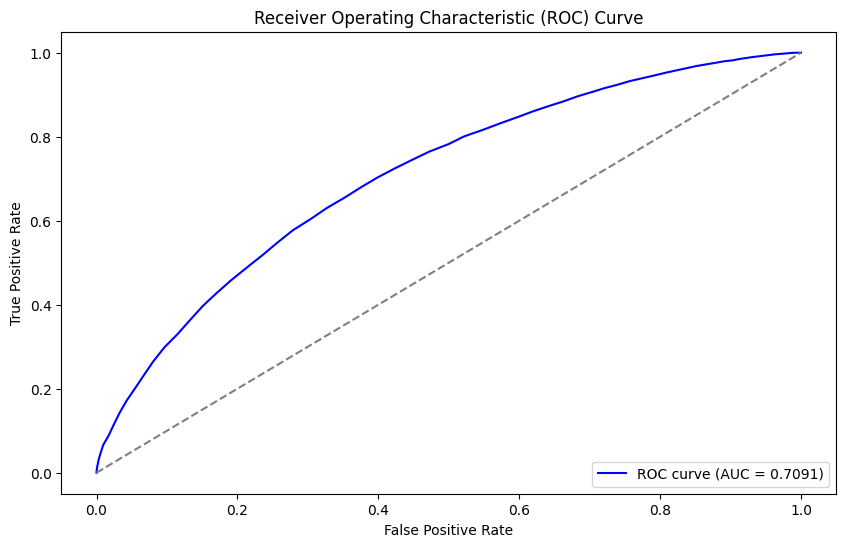

In [38]:
# Evaluasi untuk Logistic Regression
print("\n================= Logistic Regression Evaluation ==================")
evaluate_model(logreg_pipeline, X_test_strat, y_test_strat)

# Evaluasi untuk Decision Tree
print("\n================= Decision Tree Evaluation ==================")
evaluate_model(dtree_pipeline, X_test_strat, y_test_strat)
# Evaluasi untuk Random Forest
print("\n================= Random Forest Evaluation ==================")
evaluate_model(rf_pipeline, X_test_strat, y_test_strat)


# 7. Conclusion of the first experiment

Pada eksperimen pertama, penulis menguji tiga kategori model: 
1. **Baseline Linear Model**: Logistic Regression
2. **Non-Linear Model**: Decision Tree Classifier
3. **Ensemble Model (Bagging)**: Random Forest Classifier

Tujuan dari eksperimen ini adalah untuk mengevaluasi kinerja masing-masing model pada dataset dan membandingkan kelebihan serta kekurangannya dalam berbagai metrik kinerja. Berikut adalah hasil evaluasi dari masing-masing model.

---

## Logistic Regression Evaluation

Model **Logistic Regression** menunjukkan hasil evaluasi sebagai berikut:

- **Precision (Class 0)**: Model ini kurang efektif dalam memprediksi kelas 0 (misalnya, pinjaman buruk), dengan nilai precision sebesar **0.58**.
- **Recall (Class 0)**: Recall untuk kelas 0 sangat rendah (**0.10**), yang berarti model ini hampir tidak bisa mendeteksi pinjaman buruk.
- **Precision (Class 1)**: Precision untuk kelas 1 (pinjaman baik) cukup baik (**0.79**), menunjukkan bahwa ketika model memprediksi pinjaman baik, hasilnya cenderung benar.
- **Recall (Class 1)**: Model ini sangat baik dalam mendeteksi pinjaman baik dengan recall **0.98**, yang menunjukkan bahwa model dapat mendeteksi sebagian besar kasus pinjaman baik dengan sangat baik.

- **F1-Score**: Model memiliki F1-Score yang tinggi untuk kelas 1 (**0.87**), yang mengindikasikan keseimbangan yang baik antara precision dan recall untuk kelas 1.
- **Accuracy**: Akurasi keseluruhan adalah **0.78**, yang menunjukkan bahwa model ini bisa dikatakan cukup baik dalam memprediksi baik dan buruknya pinjaman secara keseluruhan.

- **ROC-AUC**: Nilai ROC-AUC sebesar **0.7059** menunjukkan bahwa model ini memiliki kemampuan yang baik untuk membedakan antara kelas 0 dan kelas 1, meskipun masih ada ruang untuk perbaikan.

---

## Decision Tree Evaluation

Model **Decision Tree** menunjukkan hasil evaluasi sebagai berikut:

- **Precision (Class 0)**: Model ini memiliki precision yang sangat rendah untuk kelas 0 (**0.32**), yang berarti model sering salah mengklasifikasikan pinjaman buruk sebagai pinjaman baik.
- **Recall (Class 0)**: Recall untuk kelas 0 adalah **0.34**, yang sedikit lebih baik, tetapi tetap menunjukkan bahwa model kesulitan dalam mendeteksi pinjaman buruk.
- **Precision (Class 1)**: Precision untuk kelas 1 adalah **0.80**, yang cukup tinggi dan menunjukkan bahwa model lebih efektif dalam memprediksi pinjaman baik dengan benar.
- **Recall (Class 1)**: Recall untuk kelas 1 adalah **0.79**, yang baik tetapi tidak setinggi Logistic Regression.

- **F1-Score**: F1-Score untuk kelas 1 adalah **0.79**, menunjukkan keseimbangan yang baik antara precision dan recall untuk kelas 1. Namun, model ini kurang seimbang dalam mendeteksi kelas 0.
- **Accuracy**: Akurasi keseluruhan model adalah **0.68**, lebih rendah dibandingkan dengan Logistic Regression, menandakan model ini kurang efektif dalam memprediksi baik dan buruknya pinjaman.

- **ROC-AUC**: Nilai ROC-AUC yang lebih rendah (**0.5635**) menunjukkan bahwa model ini kurang efektif dalam membedakan antara kelas 0 dan kelas 1.

---

## Random Forest Evaluation

Model **Random Forest** menunjukkan hasil evaluasi sebagai berikut:

- **Precision (Class 0)**: Precision untuk kelas 0 adalah **0.58**, yang masih menunjukkan bahwa model ini memiliki beberapa kesalahan dalam memprediksi pinjaman buruk.
- **Recall (Class 0)**: Recall untuk kelas 0 sangat rendah (**0.14**), yang menunjukkan bahwa model ini jarang mendeteksi pinjaman buruk.
- **Precision (Class 1)**: Precision untuk kelas 1 adalah **0.79**, mirip dengan hasil Logistic Regression dan menunjukkan bahwa model ini cukup baik dalam memprediksi pinjaman baik.
- **Recall (Class 1)**: Recall untuk kelas 1 adalah **0.97**, yang sangat tinggi, menandakan bahwa model ini sangat baik dalam mendeteksi pinjaman baik.

- **F1-Score**: F1-Score untuk kelas 1 adalah **0.87**, yang juga menunjukkan keseimbangan yang baik antara precision dan recall untuk kelas 1.
- **Accuracy**: Akurasi keseluruhan model adalah **0.78**, yang sama dengan Logistic Regression, namun model ini masih kurang efektif dalam mendeteksi kelas 0 (pinjaman buruk).

- **ROC-AUC**: Nilai ROC-AUC **0.7031** menunjukkan bahwa model ini memiliki kemampuan yang lebih baik dibandingkan Decision Tree dalam membedakan kelas 0 dan kelas 1, meskipun hasilnya masih kalah dari Logistic Regression.

---

### Summary of Results:

1. **Logistic Regression** menunjukkan kinerja terbaik dalam hal **recall** untuk kelas 1 (**0.98**) dan akurasi keseluruhan (**0.78**), meskipun kurang efektif dalam memprediksi kelas 0.
2. **Decision Tree** memiliki performa yang lebih buruk, dengan **precision** dan **recall** yang lebih rendah untuk kelas 0, namun tetap menunjukkan **precision** dan **recall** yang baik untuk kelas 1.
3. **Random Forest** menunjukkan performa yang lebih baik dalam hal **recall** untuk kelas 1 (**0.97**) tetapi memiliki **recall** yang rendah untuk kelas 0 (**0.14**).

Masing-masing model memiliki kelebihan dan kekurangan tergantung pada kelas yang diprediksi. Logistic Regression dan Random Forest lebih unggul dalam mendeteksi pinjaman baik, sedangkan Decision Tree kurang efektif dalam membedakan antara kedua kelas.

---

**Catatan**: Evaluasi ini memberi gambaran tentang bagaimana model-model ini bekerja dengan dataset yang ada. Untuk pengoptimalan lebih lanjut, mungkin perlu dilakukan teknik lain seperti hyperparameter tuning atau feature engineering.


## Eksperimen 2: Penerapan SMOTE dan Hyperparameter Tuning

Pada eksperimen pertama, saya telah menguji tiga kategori model untuk mengukur kinerja prediksi pada dataset pinjaman. Meskipun hasil eksperimen pertama menunjukkan performa yang cukup baik, ksaya menyadari bahwa salah satu masalah utama yang muncul adalah ketidakseimbangan kelas antara pinjaman baik (kelas 1) dan pinjaman buruk (kelas 0).

### Tujuan Eksperimen 2

Eksperimen kedua bertujuan untuk meningkatkan kinerja model dengan menangani masalah ketidakseimbangan kelas menggunakan teknik **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE bertujuan untuk menyeimbangkan distribusi kelas dengan cara menghasilkan data sintetik untuk kelas minoritas (kelas 0).

Selain itu, setelah mengatasi ketidakseimbangan kelas, kita akan melanjutkan dengan **hyperparameter tuning** pada model yang sudah diseimbangkan untuk meningkatkan performa prediksi. Teknik tuning ini bertujuan untuk mencari kombinasi parameter terbaik yang dapat meningkatkan kemampuan model dalam memprediksi kedua kelas secara lebih akurat.

### Langkah-langkah Eksperimen 2

1. **Penerapan SMOTE pada Data Training**

   - SMOTE akan diterapkan pada data training setelah dilakukan data splitting (train–test). Data test set tidak akan dikenakan SMOTE, agar hasil evaluasi tetap mencerminkan performa model pada data yang belum terlihat sebelumnya.
   - Teknik ini akan menambah jumlah sampel untuk kelas minoritas (misalnya pinjaman buruk) dengan menghasilkan sampel sintetik berdasarkan distribusi fitur yang ada pada kelas tersebut.

2. **Hyperparameter Tuning**

   - Setelah SMOTE diterapkan, kita akan melakukan hyperparameter tuning pada masing-masing model (Logistic Regression, Decision Tree, dan Random Forest) menggunakan `GridSearchCV` atau `RandomizedSearchCV` untuk mencari kombinasi parameter terbaik.
   - Hal ini bertujuan untuk mendapatkan model yang lebih optimal pada data yang sudah diseimbangkan.

3. **Evaluasi Model**

   - Setelah tuning selesai, kita akan mengevaluasi model menggunakan data test untuk melihat seberapa baik model bekerja setelah diterapkan teknik SMOTE dan tuning parameter.
   - Metrik evaluasi yang akan digunakan meliputi **precision, recall, F1-Score, AUC-ROC, dan accuracy** untuk menilai kinerja model dalam memprediksi kelas 0 (pinjaman buruk) dan kelas 1 (pinjaman baik).

### Kenapa SMOTE dan Tuning?

- **SMOTE**

  Dalam eksperimen pertama, model kesulitan dalam mendeteksi kelas 0 (pinjaman buruk), seperti yang terlihat dari nilai *recall* yang rendah pada kelas 0. SMOTE membantu dengan memberikan lebih banyak data untuk kelas minoritas, sehingga model dapat belajar mengenali pola yang lebih baik pada kelas tersebut.

- **Hyperparameter Tuning**

  Pengaturan parameter yang tepat bisa sangat memengaruhi kinerja model, baik dalam hal akurasi maupun kemampuan untuk menangani ketidakseimbangan kelas. Dengan tuning, kita berharap dapat meningkatkan kemampuan model dalam membedakan antara kedua kelas.

### Implementasi Eksperimen 2

Eksperimen 2 akan mencakup langkah-langkah berikut:

1. Menggunakan SMOTE untuk menyeimbangkan data training.
2. Melakukan hyperparameter tuning menggunakan `GridSearchCV` atau `RandomizedSearchCV`.
3. Mengevaluasi model pada test set menggunakan metrik evaluasi yang telah ditentukan.




# **Eksperimen 2: SMOTE + baseline / SMOTE + tuning**

# 8. Splitting & Preprocessing

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1️⃣ Numeric Pipeline
numeric_transformer_exp2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputasi median untuk numeric
    ('scaler', StandardScaler())  # Scaling numeric
])

# 2️⃣ Categorical Pipeline
categorical_transformer_exp2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputasi modus
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # sparse=False supaya kompatibel SMOTE
])

# 3️⃣ Gabungkan dalam ColumnTransformer khusus eksperimen 2
preprocessor_exp2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_exp2, features_numeric_safe),
        ('cat', categorical_transformer_exp2, features_categorical_safe)
    ]
)
print("Preprocessor Eksperimen 2 Setup Sukses!")


Preprocessor Eksperimen 2 Setup Sukses!


In [40]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline  # Agar SMOTE bisa masuk pipeline

X2 = df_model_clean.drop(columns='target')
y2 = df_model_clean['target']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)


# 9. Define function for Evaluation

In [41]:
# Confusion matrix
def plot_confusion_matrix_exp2(y2_test, y2_pred):
    cm = confusion_matrix(y2_test, y2_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nPenjelasan Confusion Matrix:")
    print(f"True Positives (TP): {cm[1, 1]}")
    print(f"True Negatives (TN): {cm[0, 0]}")
    print(f"False Positives (FP): {cm[0, 1]}")
    print(f"False Negatives (FN): {cm[1, 0]}")
    
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1'], 
                yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [42]:
# Classification report
def plot_classification_report_exp2(y2_test, y2_pred):
    report = classification_report(y2_test, y2_pred)
    print("\nClassification Report:")
    print(report)


In [43]:
# ROC Curve & AUC
def plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob):
    fpr, tpr, thresholds = roc_curve(y2_test, y2_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    print(f"\nROC-AUC Score: {roc_auc:.4f}")
    return roc_auc

In [44]:
# Precision-Recall & AUC
def plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob):
    precision, recall, _ = precision_recall_curve(y2_test, y2_pred_prob)
    auc_pr = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', lw=2, label=f'Precision-Recall curve (AUC = {auc_pr:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

    print(f"\nAUC-PR: {auc_pr:.4f}")
    return auc_pr

In [45]:
# Gini Index
def plot_gini_index_exp2(roc_auc):
    gini_index = 2 * roc_auc - 1
    print(f"\nGini Index: {gini_index:.4f}")

In [46]:
# 🔹 Evaluate Model Function - Eksperimen 2
def evaluate_model_exp2(pipeline, X2_test, y2_test):
    # Prediksi
    y2_pred = pipeline.predict(X2_test)
    y2_pred_prob = pipeline.predict_proba(X2_test)[:, 1]  # Probabilitas class 1

    # 1. Confusion Matrix
    plot_confusion_matrix_exp2(y2_test, y2_pred)

    # 2. Classification Report
    plot_classification_report_exp2(y2_test, y2_pred)

    # 3. ROC-AUC Score
    roc_auc = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob)

    # 4. Gini Index
    plot_gini_index_exp2(roc_auc)

    # 5. Precision-Recall & AUC
    plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob)


# 10. Training 

## 2A

In [47]:
# # Hanya untuk fitur kategorikal
# cat_features_encoded = preprocessor_exp2.named_transformers_['cat']['onehot'].get_feature_names_out(features_categorical_safe)
# print("Fitur kategorikal setelah encoding:", cat_features_encoded)

# # Semua fitur (numeric + one-hot)
# all_features = np.concatenate([features_numeric_safe, cat_features_encoded])
# print("Jumlah total fitur:", len(all_features))


In [48]:
# Logistic Regression pipeline
lr_pipeline_exp2 = ImbPipeline([
    ('preprocessor', preprocessor_exp2),          # Pakai preprocessor versi 2
    ('smote', SMOTE(random_state=42)),            # Oversampling SMOTE
    ('classifier', LogisticRegression(max_iter=500, random_state=42))
])

# Decision Tree pipeline
dt_pipeline_exp2 = ImbPipeline([
    ('preprocessor', preprocessor_exp2),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Random Forest pipeline
rf_pipeline_exp2 = ImbPipeline([
    ('preprocessor', preprocessor_exp2),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])



=== Eksperimen 2A: Logistic Regression ===

Confusion Matrix:
[[ 7279  3556]
 [13709 23239]]

Penjelasan Confusion Matrix:
True Positives (TP): 23239
True Negatives (TN): 7279
False Positives (FP): 3556
False Negatives (FN): 13709


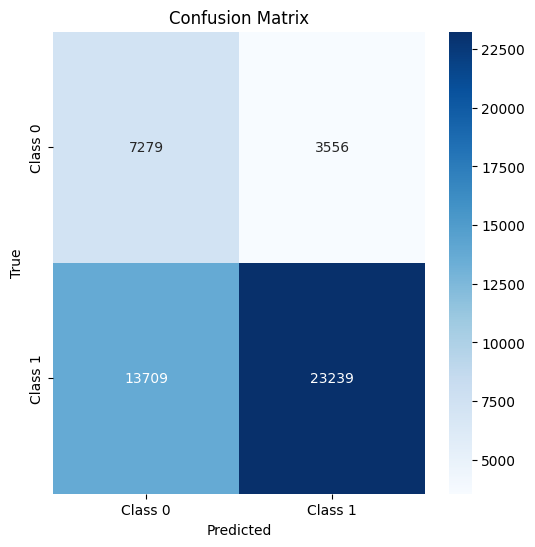


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46     10835
           1       0.87      0.63      0.73     36948

    accuracy                           0.64     47783
   macro avg       0.61      0.65      0.59     47783
weighted avg       0.75      0.64      0.67     47783



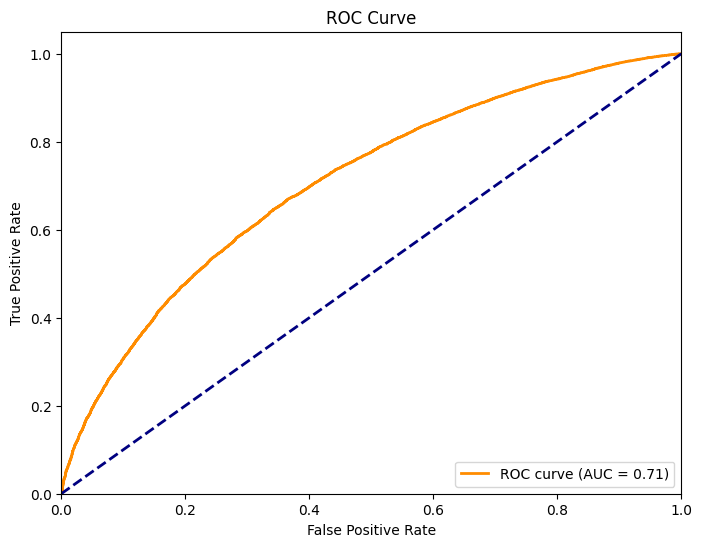


ROC-AUC Score: 0.7070

Gini Index: 0.4141


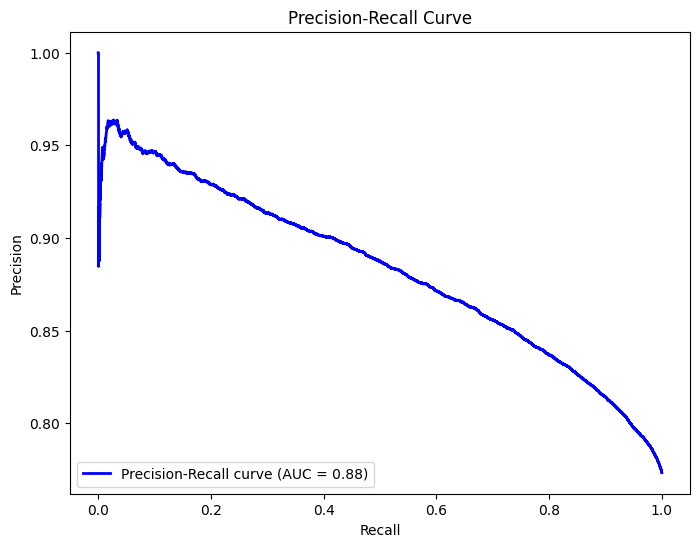


AUC-PR: 0.8825


In [49]:
# Logistic Regression training
print("\n=== Eksperimen 2A: Logistic Regression ===")
lr_pipeline_exp2.fit(X2_train, y2_train)         # Fit pipeline ke data train
evaluate_model_exp2(lr_pipeline_exp2, X2_test, y2_test)  # Evaluasi
checkpoint.save_model(lr_pipeline_exp2, "exp2_strat_smote", "CP7_exp2_smote_logreg.joblib")


=== Eksperimen 2A: Decision Tree ===

Confusion Matrix:
[[ 3928  6907]
 [ 8797 28151]]

Penjelasan Confusion Matrix:
True Positives (TP): 28151
True Negatives (TN): 3928
False Positives (FP): 6907
False Negatives (FN): 8797


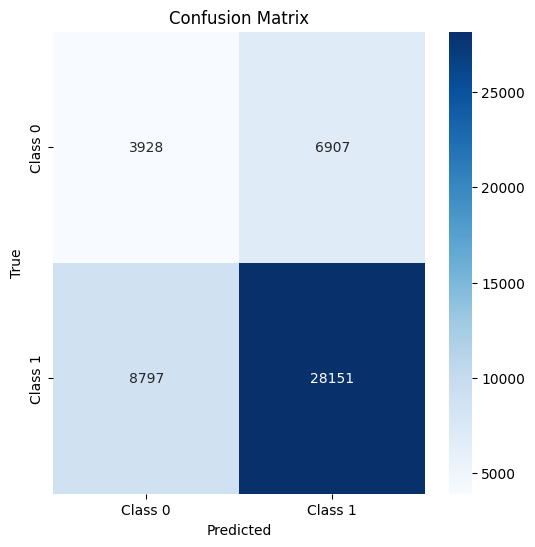


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.36      0.33     10835
           1       0.80      0.76      0.78     36948

    accuracy                           0.67     47783
   macro avg       0.56      0.56      0.56     47783
weighted avg       0.69      0.67      0.68     47783



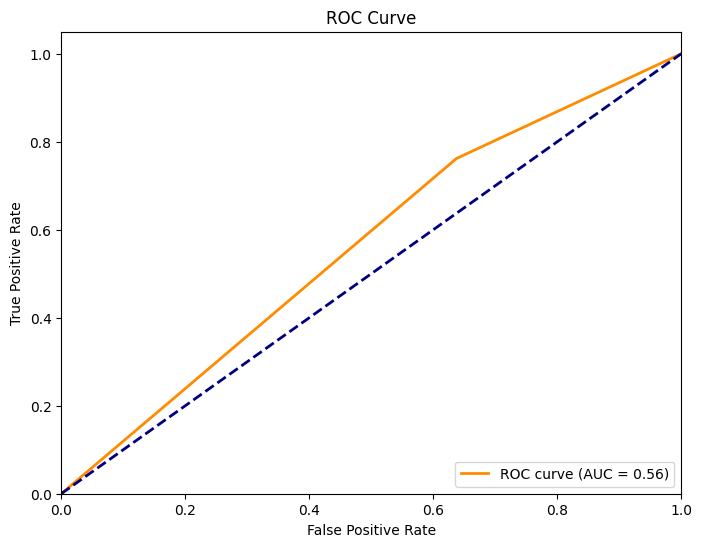


ROC-AUC Score: 0.5622

Gini Index: 0.1244


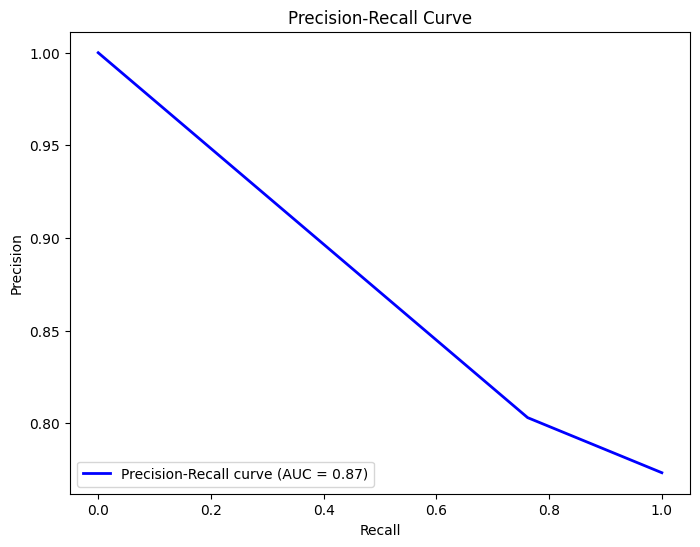


AUC-PR: 0.8745


In [50]:
# Decision Tree training
print("\n=== Eksperimen 2A: Decision Tree ===")
dt_pipeline_exp2.fit(X2_train, y2_train)
evaluate_model_exp2(dt_pipeline_exp2, X2_test, y2_test)
checkpoint.save_model(dt_pipeline_exp2, "exp2_strat_smote", "CP7_exp2_smote_dt.joblib")


=== Eksperimen 2A: Random Forest ===

Confusion Matrix:
[[ 3157  7678]
 [ 3849 33099]]

Penjelasan Confusion Matrix:
True Positives (TP): 33099
True Negatives (TN): 3157
False Positives (FP): 7678
False Negatives (FN): 3849


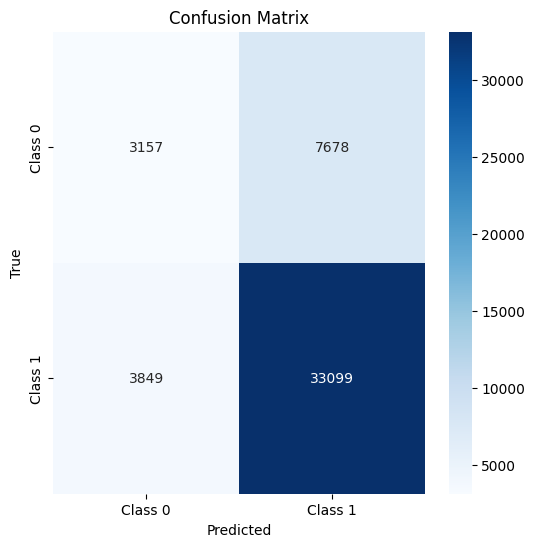


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.29      0.35     10835
           1       0.81      0.90      0.85     36948

    accuracy                           0.76     47783
   macro avg       0.63      0.59      0.60     47783
weighted avg       0.73      0.76      0.74     47783



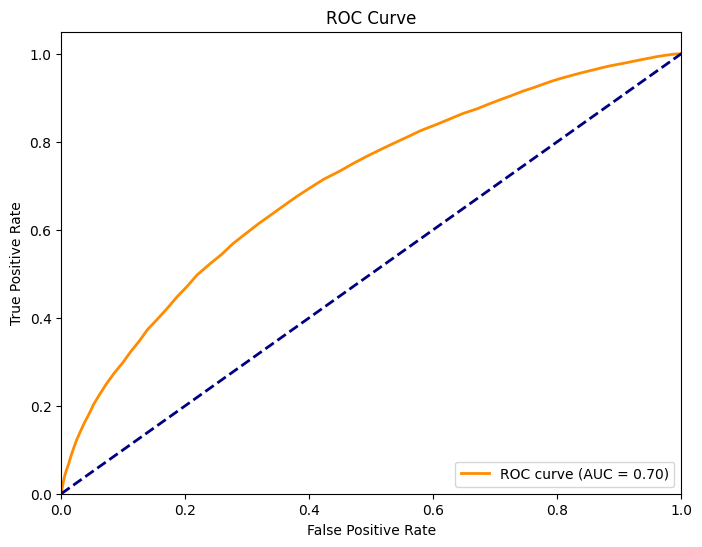


ROC-AUC Score: 0.7020

Gini Index: 0.4040


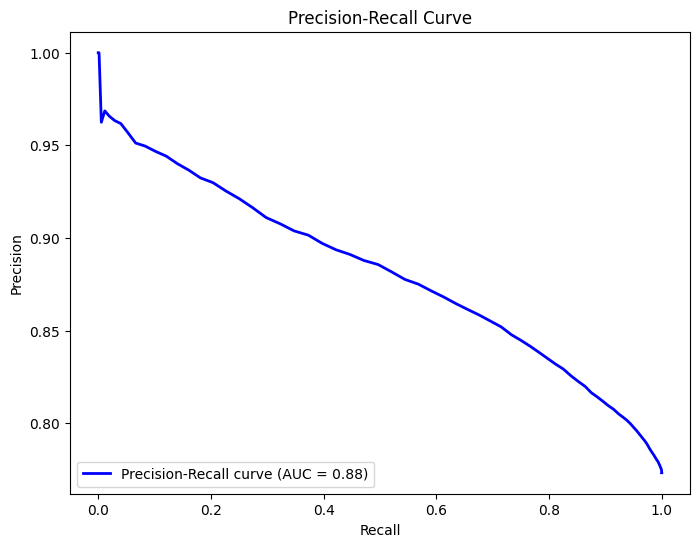


AUC-PR: 0.8816


In [51]:
# Random Forest training
print("\n=== Eksperimen 2A: Random Forest ===")
rf_pipeline_exp2.fit(X2_train, y2_train)
evaluate_model_exp2(rf_pipeline_exp2, X2_test, y2_test)
checkpoint.save_model(rf_pipeline_exp2, "exp2_strat_smote", "CP7_exp2_smote_rf.joblib")

## 2B


=== Eksperimen 2B: Logistic Regression Tuned ===
Best LR Params: {'classifier__C': 0.01, 'classifier__penalty': 'l1'}

Confusion Matrix:
[[ 7154  3681]
 [13419 23529]]

Penjelasan Confusion Matrix:
True Positives (TP): 23529
True Negatives (TN): 7154
False Positives (FP): 3681
False Negatives (FN): 13419


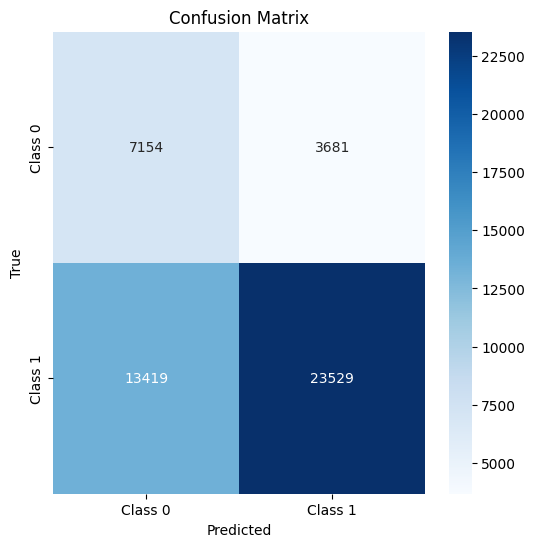


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.66      0.46     10835
           1       0.86      0.64      0.73     36948

    accuracy                           0.64     47783
   macro avg       0.61      0.65      0.59     47783
weighted avg       0.75      0.64      0.67     47783



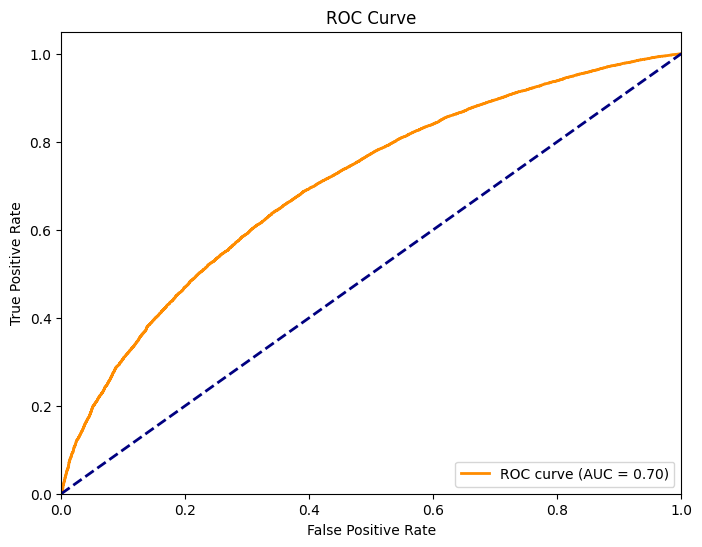


ROC-AUC Score: 0.7029

Gini Index: 0.4057


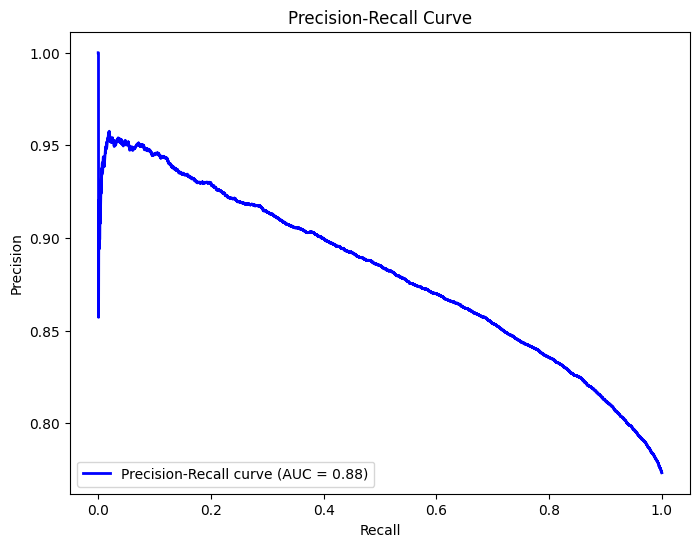


AUC-PR: 0.8806


In [52]:
# ================================
# Eksperimen 2B: SMOTE + Tuning (Logistic Regression)
# ================================

print("\n=== Eksperimen 2B: Logistic Regression Tuned ===")

# Pipeline khusus eksperimen 2B
lr_pipeline_exp2_tuned = ImbPipeline([
    ('preprocessor', preprocessor_exp2),           # Pakai preprocessor versi eksperimen 2
    ('smote', SMOTE(random_state=42)),             # Oversampling SMOTE
    ('classifier', LogisticRegression(
        max_iter=1000, random_state=42, solver='liblinear'))
])

# Grid parameter tuning - OPTIMAL
param_grid_lr_exp2 = {
    'classifier__C': [0.01, 0.1, 1, 10],      # 4 opsi (dari 5)
    'classifier__penalty': ['l1', 'l2']        # 2 opsi
}  # Total: 4 × 2 × 3 (cv) = 24 kombinasi

# GridSearchCV - RINGAN
grid_lr_exp2 = GridSearchCV(
    lr_pipeline_exp2_tuned, 
    param_grid_lr_exp2, 
    cv=3,              # cv=3 (dari 5)
    scoring='roc_auc', 
    n_jobs=2           # n_jobs=2 (dari -1)
)

# Fit ke data train eksperimen 2
grid_lr_exp2.fit(X2_train, y2_train)

# Ambil estimator terbaik
best_lr_exp2 = grid_lr_exp2.best_estimator_
print("Best LR Params:", grid_lr_exp2.best_params_)

# Evaluasi model
evaluate_model_exp2(best_lr_exp2, X2_test, y2_test)

# Save checkpoint model dan parameter
checkpoint.save_model(best_lr_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_logreg.joblib")
checkpoint.save_json(grid_lr_exp2.best_params_, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_logreg_params.json")

# Hitung dan simpan metrics tambahan
y_pred_exp2 = best_lr_exp2.predict(X2_test)
y_pred_proba_exp2 = best_lr_exp2.predict_proba(X2_test)[:, 1]

metrics_exp2 = {
    'accuracy': accuracy_score(y2_test, y_pred_exp2),
    'precision': precision_score(y2_test, y_pred_exp2, zero_division=0),
    'recall': recall_score(y2_test, y_pred_exp2, zero_division=0),
    'f1': f1_score(y2_test, y_pred_exp2, zero_division=0),
    'roc_auc': roc_auc_score(y2_test, y_pred_proba_exp2),
    'best_score': float(grid_lr_exp2.best_score_)
}

checkpoint.save_json(metrics_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_logreg_metrics.json")


=== Eksperimen 2B: Decision Tree Tuned ===
Best DT Params: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Confusion Matrix:
[[ 6153  4682]
 [14440 22508]]

Penjelasan Confusion Matrix:
True Positives (TP): 22508
True Negatives (TN): 6153
False Positives (FP): 4682
False Negatives (FN): 14440


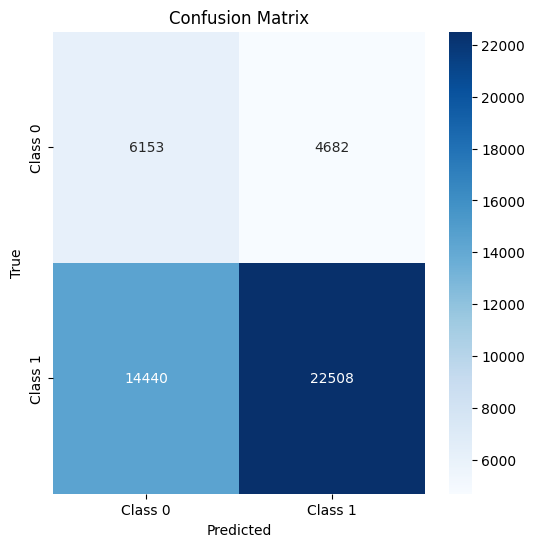


Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.57      0.39     10835
           1       0.83      0.61      0.70     36948

    accuracy                           0.60     47783
   macro avg       0.56      0.59      0.55     47783
weighted avg       0.71      0.60      0.63     47783



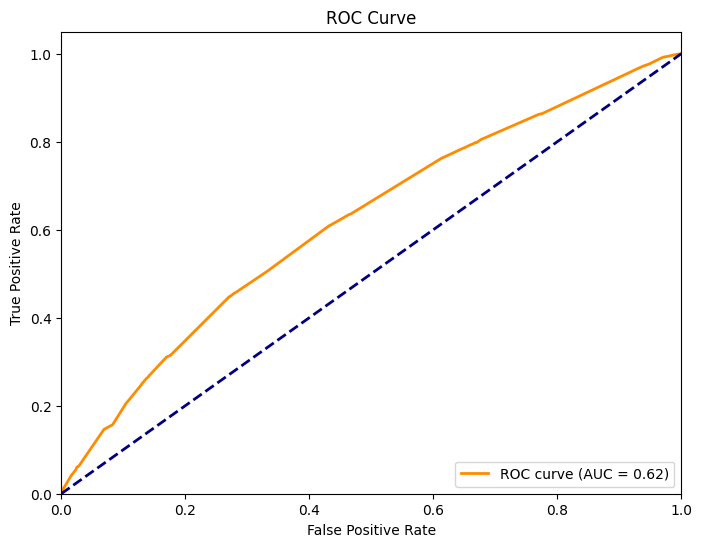


ROC-AUC Score: 0.6178

Gini Index: 0.2356


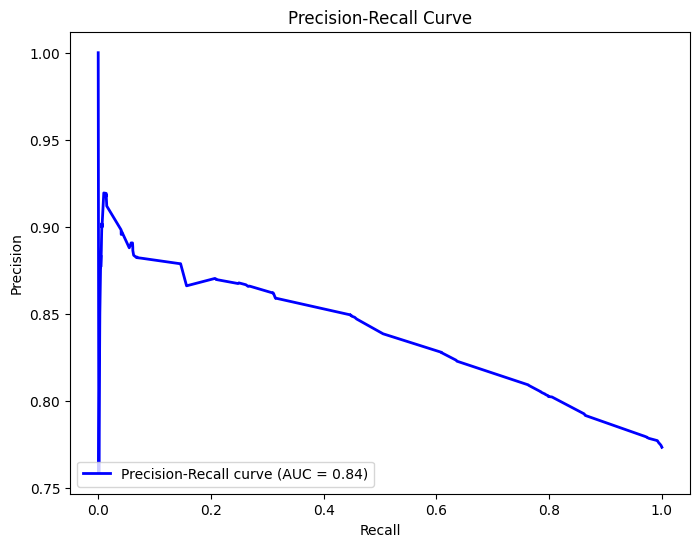


AUC-PR: 0.8378


In [53]:
# ================================
# Eksperimen 2B: SMOTE + Tuning (Decision Tree)
# ================================

print("\n=== Eksperimen 2B: Decision Tree Tuned ===")

# Pipeline khusus eksperimen 2B
dt_pipeline_exp2_tuned = ImbPipeline([
    ('preprocessor', preprocessor_exp2),           # Pakai preprocessor versi eksperimen 2
    ('smote', SMOTE(random_state=42)),             # Oversampling SMOTE
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Grid parameter tuning - OPTIMAL
param_grid_dt_exp2 = {
    'classifier__max_depth': [8, 15, None],        # 3 opsi (dari 5)
    'classifier__min_samples_split': [2, 6],       # 2 opsi (dari 4)
    'classifier__min_samples_leaf': [1, 4],        # 2 opsi (dari 4)
    'classifier__max_features': ['sqrt', None]     # 2 opsi (dari 3)
}  # Total: 3 × 2 × 2 × 2 × 3 (cv) = 72 kombinasi

# GridSearchCV - RINGAN
grid_dt_exp2 = GridSearchCV(
    dt_pipeline_exp2_tuned,
    param_grid_dt_exp2,
    cv=3,              # cv=3 (dari 5)
    scoring='roc_auc',
    n_jobs=2           # n_jobs=2 (dari -1)
)

# Fit ke data train eksperimen 2
grid_dt_exp2.fit(X2_train, y2_train)

# Ambil estimator terbaik
best_dt_exp2 = grid_dt_exp2.best_estimator_
print("Best DT Params:", grid_dt_exp2.best_params_)

# Evaluasi model
evaluate_model_exp2(best_dt_exp2, X2_test, y2_test)

# Save checkpoint model dan parameter
checkpoint.save_model(best_dt_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_dt.joblib")
checkpoint.save_json(grid_dt_exp2.best_params_, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_dt_params.json")

# Hitung dan simpan metrics tambahan
y_pred_dt_exp2 = best_dt_exp2.predict(X2_test)
y_pred_proba_dt_exp2 = best_dt_exp2.predict_proba(X2_test)[:, 1]

metrics_dt_exp2 = {
    'accuracy': accuracy_score(y2_test, y_pred_dt_exp2),
    'precision': precision_score(y2_test, y_pred_dt_exp2, zero_division=0),
    'recall': recall_score(y2_test, y_pred_dt_exp2, zero_division=0),
    'f1': f1_score(y2_test, y_pred_dt_exp2, zero_division=0),
    'roc_auc': roc_auc_score(y2_test, y_pred_proba_dt_exp2),
    'best_score': float(grid_dt_exp2.best_score_)
}

checkpoint.save_json(metrics_dt_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_dt_metrics.json")


=== Eksperimen 2B: Random Forest Tuned ===
Best RF Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Confusion Matrix:
[[ 4851  5984]
 [ 6893 30055]]

Penjelasan Confusion Matrix:
True Positives (TP): 30055
True Negatives (TN): 4851
False Positives (FP): 5984
False Negatives (FN): 6893


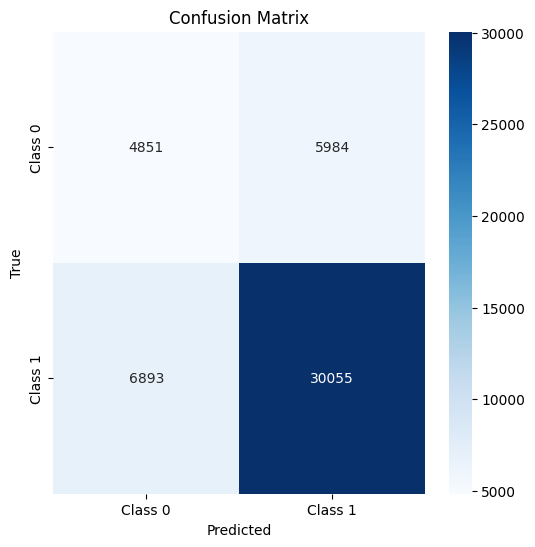


Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     10835
           1       0.83      0.81      0.82     36948

    accuracy                           0.73     47783
   macro avg       0.62      0.63      0.63     47783
weighted avg       0.74      0.73      0.73     47783



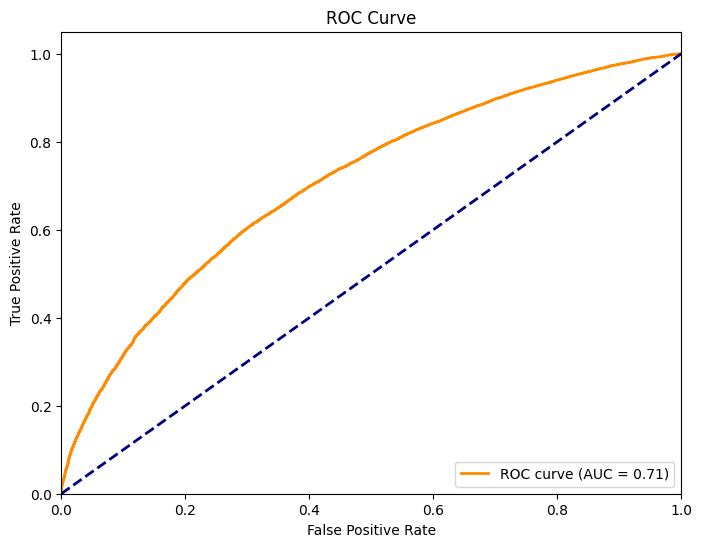


ROC-AUC Score: 0.7071

Gini Index: 0.4142


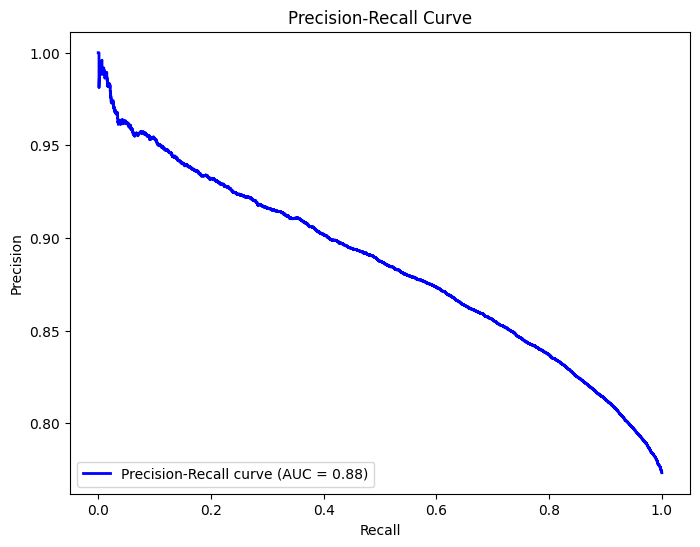


AUC-PR: 0.8848


In [54]:
# ================================
# Eksperimen 2B: SMOTE + Tuning (Random Forest)
# ================================

print("\n=== Eksperimen 2B: Random Forest Tuned ===")

# Pipeline khusus eksperimen 2B
rf_pipeline_exp2_tuned = ImbPipeline([
    ('preprocessor', preprocessor_exp2),           # Pakai preprocessor versi eksperimen 2
    ('smote', SMOTE(random_state=42)),             # Oversampling SMOTE
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=2))
])

# Grid parameter tuning - OPTIMAL (RAM-friendly)
param_grid_rf_exp2 = {
    'classifier__n_estimators': [100, 200],           # 2 opsi (dari 3)
    'classifier__max_depth': [20, None],              # 2 opsi (dari 3)
    'classifier__min_samples_leaf': [1, 4],           # 2 opsi (dari 3)
    'classifier__max_features': ['sqrt']              # 1 opsi (dari 3) - sqrt adalah best practice
}  # Total: 2 × 2 × 2 × 1 × 3 (cv) = 24 kombinasi (dari 405!)

# GridSearchCV - RINGAN
grid_rf_exp2 = GridSearchCV(
    rf_pipeline_exp2_tuned,
    param_grid_rf_exp2,
    cv=3,              # cv=3 (dari 5)
    scoring='roc_auc',
    n_jobs=2           # n_jobs=2 (dari -1) - pakai 2 core saja
)

# Fit ke data train eksperimen 2
grid_rf_exp2.fit(X2_train, y2_train)

# Ambil estimator terbaik
best_rf_exp2 = grid_rf_exp2.best_estimator_
print("Best RF Params:", grid_rf_exp2.best_params_)

# Evaluasi model
evaluate_model_exp2(best_rf_exp2, X2_test, y2_test)

# Save checkpoint model dan parameter
checkpoint.save_model(best_rf_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_rf.joblib")
checkpoint.save_json(grid_rf_exp2.best_params_, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_rf_params.json")

# Hitung dan simpan metrics tambahan
y_pred_rf_exp2 = best_rf_exp2.predict(X2_test)
y_pred_proba_rf_exp2 = best_rf_exp2.predict_proba(X2_test)[:, 1]

metrics_rf_exp2 = {
    'accuracy': accuracy_score(y2_test, y_pred_rf_exp2),
    'precision': precision_score(y2_test, y_pred_rf_exp2, zero_division=0),
    'recall': recall_score(y2_test, y_pred_rf_exp2, zero_division=0),
    'f1': f1_score(y2_test, y_pred_rf_exp2, zero_division=0),
    'roc_auc': roc_auc_score(y2_test, y_pred_proba_rf_exp2),
    'best_score': float(grid_rf_exp2.best_score_)
}

checkpoint.save_json(metrics_rf_exp2, "exp2_strat_smote_tuned", "CP8_exp2_smote_tuned_rf_metrics.json")

# 10. Testing & Evaluation

## 2A


Confusion Matrix:
[[ 7279  3556]
 [13709 23239]]

Penjelasan Confusion Matrix:
True Positives (TP): 23239
True Negatives (TN): 7279
False Positives (FP): 3556
False Negatives (FN): 13709


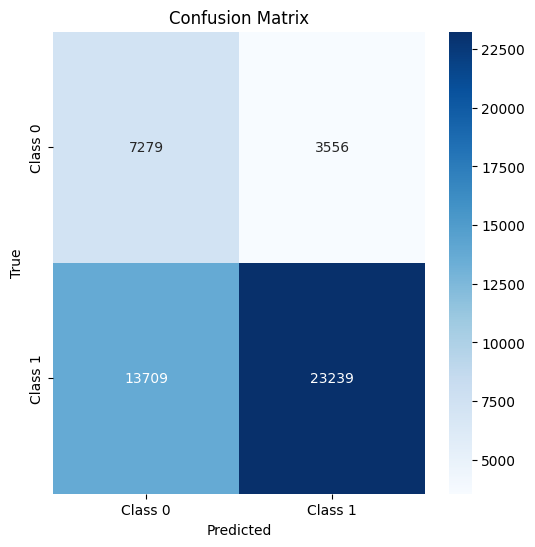


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46     10835
           1       0.87      0.63      0.73     36948

    accuracy                           0.64     47783
   macro avg       0.61      0.65      0.59     47783
weighted avg       0.75      0.64      0.67     47783



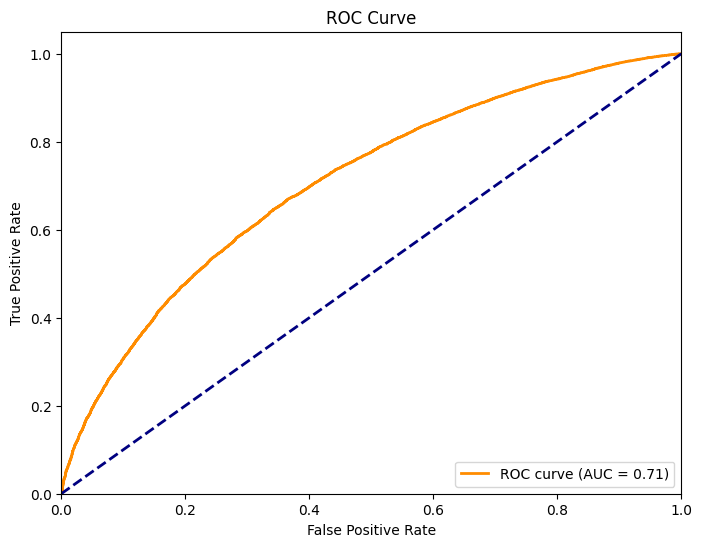


ROC-AUC Score: 0.7070


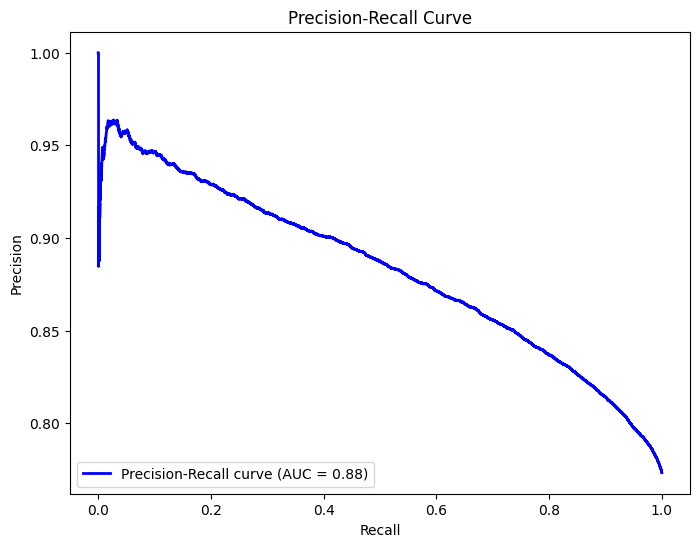


AUC-PR: 0.8825

Gini Index: 0.4141


In [55]:
# Evaluasi untuk Eksperimen 2A: Logistic Regression
y2_pred_lr = lr_pipeline_exp2.predict(X2_test)
y2_pred_prob_lr = lr_pipeline_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_lr)
plot_classification_report_exp2(y2_test, y2_pred_lr)
roc_auc_lr = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_lr)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_lr)
plot_gini_index_exp2(roc_auc_lr)


Confusion Matrix:
[[ 3928  6907]
 [ 8797 28151]]

Penjelasan Confusion Matrix:
True Positives (TP): 28151
True Negatives (TN): 3928
False Positives (FP): 6907
False Negatives (FN): 8797


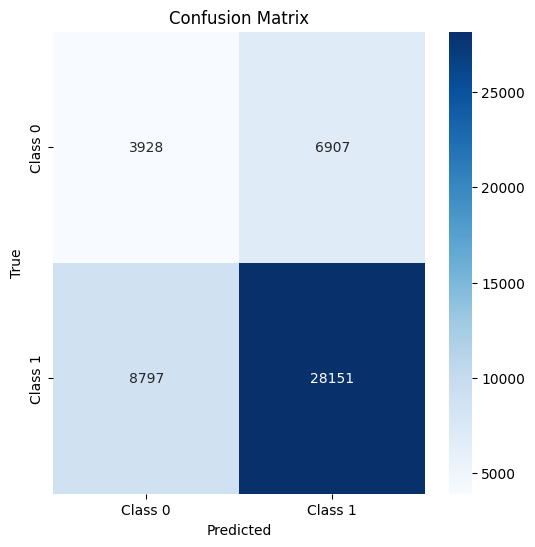


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.36      0.33     10835
           1       0.80      0.76      0.78     36948

    accuracy                           0.67     47783
   macro avg       0.56      0.56      0.56     47783
weighted avg       0.69      0.67      0.68     47783



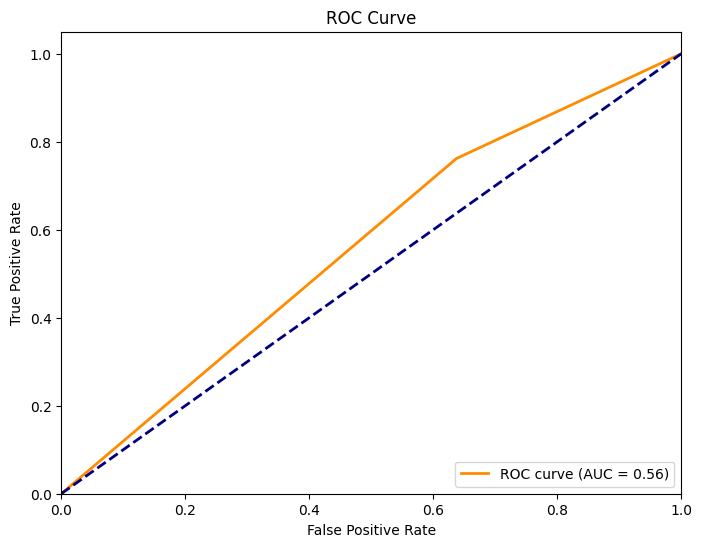


ROC-AUC Score: 0.5622


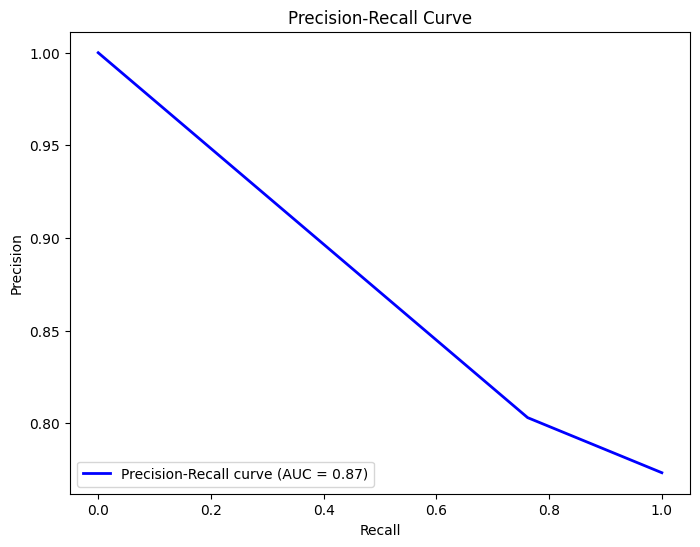


AUC-PR: 0.8745

Gini Index: 0.1244


In [56]:
# Evaluasi untuk Eksperimen 2A: Decision Tree
y2_pred_dt = dt_pipeline_exp2.predict(X2_test)
y2_pred_prob_dt = dt_pipeline_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_dt)
plot_classification_report_exp2(y2_test, y2_pred_dt)
roc_auc_dt = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_dt)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_dt)
plot_gini_index_exp2(roc_auc_dt)


Confusion Matrix:
[[ 3157  7678]
 [ 3849 33099]]

Penjelasan Confusion Matrix:
True Positives (TP): 33099
True Negatives (TN): 3157
False Positives (FP): 7678
False Negatives (FN): 3849


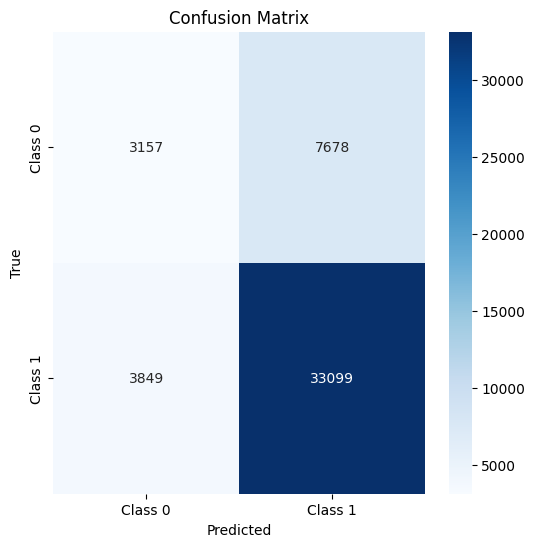


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.29      0.35     10835
           1       0.81      0.90      0.85     36948

    accuracy                           0.76     47783
   macro avg       0.63      0.59      0.60     47783
weighted avg       0.73      0.76      0.74     47783



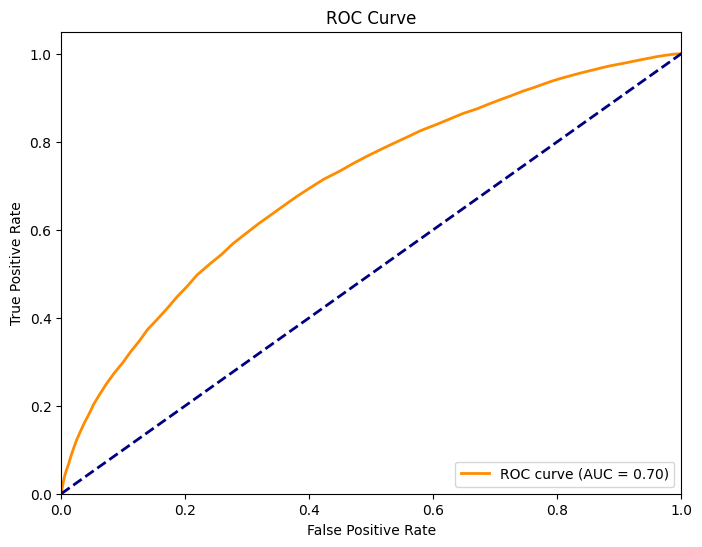


ROC-AUC Score: 0.7020


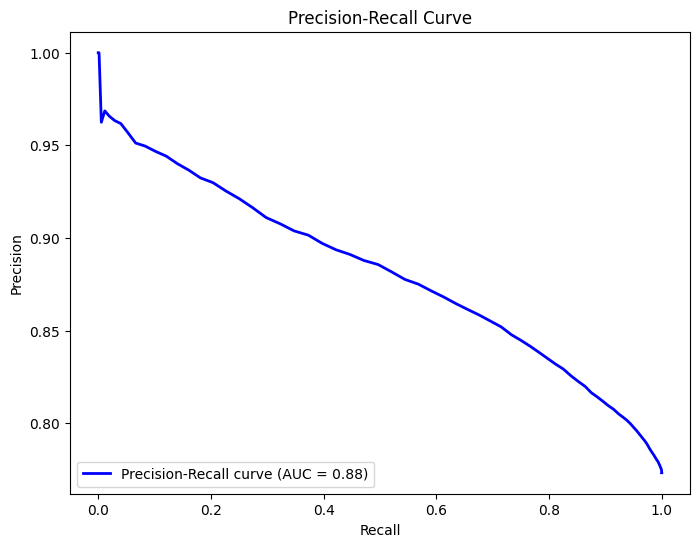


AUC-PR: 0.8816

Gini Index: 0.4040


In [57]:
# Evaluasi untuk Eksperimen 2A: Random Forest
y2_pred_rf = rf_pipeline_exp2.predict(X2_test)
y2_pred_prob_rf = rf_pipeline_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_rf)
plot_classification_report_exp2(y2_test, y2_pred_rf)
roc_auc_rf = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_rf)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_rf)
plot_gini_index_exp2(roc_auc_rf)

## 2B


Confusion Matrix:
[[ 7154  3681]
 [13419 23529]]

Penjelasan Confusion Matrix:
True Positives (TP): 23529
True Negatives (TN): 7154
False Positives (FP): 3681
False Negatives (FN): 13419


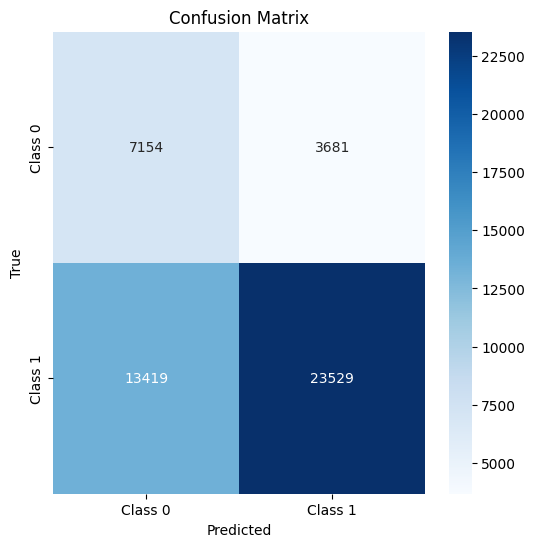


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.66      0.46     10835
           1       0.86      0.64      0.73     36948

    accuracy                           0.64     47783
   macro avg       0.61      0.65      0.59     47783
weighted avg       0.75      0.64      0.67     47783



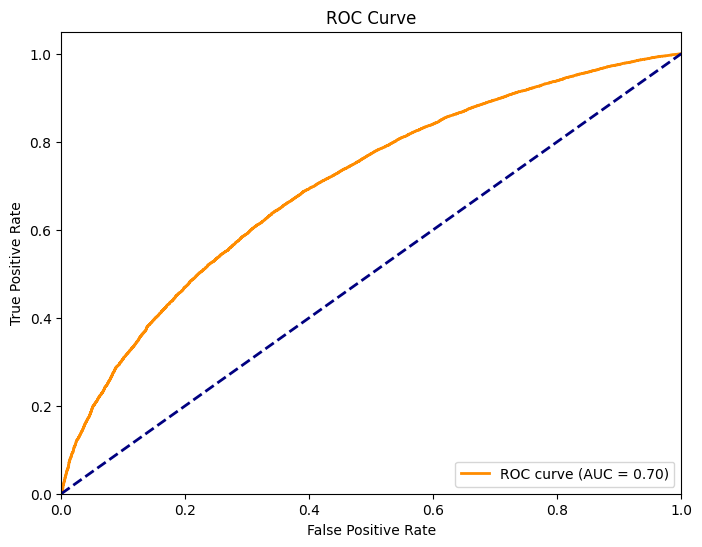


ROC-AUC Score: 0.7029


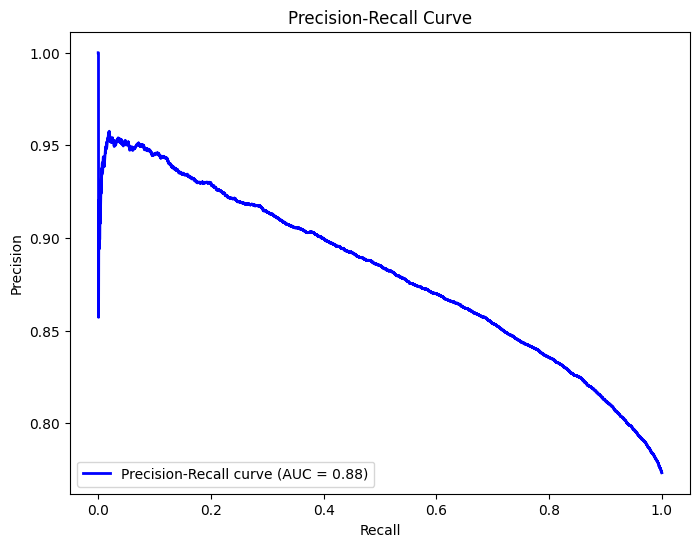


AUC-PR: 0.8806

Gini Index: 0.4057


In [58]:
# Evaluasi Eksperimen 2B: Logistic Regression Tuned
y2_pred_lr_tuned = best_lr_exp2.predict(X2_test)
y2_pred_prob_lr_tuned = best_lr_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_lr_tuned)
plot_classification_report_exp2(y2_test, y2_pred_lr_tuned)
roc_auc_lr_tuned = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_lr_tuned)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_lr_tuned)
plot_gini_index_exp2(roc_auc_lr_tuned)


Confusion Matrix:
[[ 6153  4682]
 [14440 22508]]

Penjelasan Confusion Matrix:
True Positives (TP): 22508
True Negatives (TN): 6153
False Positives (FP): 4682
False Negatives (FN): 14440


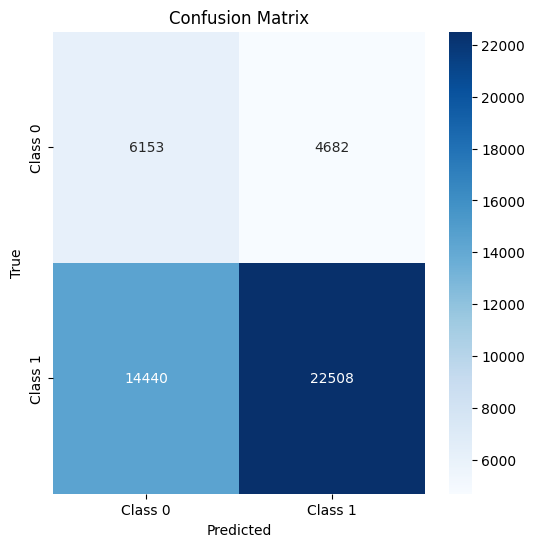


Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.57      0.39     10835
           1       0.83      0.61      0.70     36948

    accuracy                           0.60     47783
   macro avg       0.56      0.59      0.55     47783
weighted avg       0.71      0.60      0.63     47783



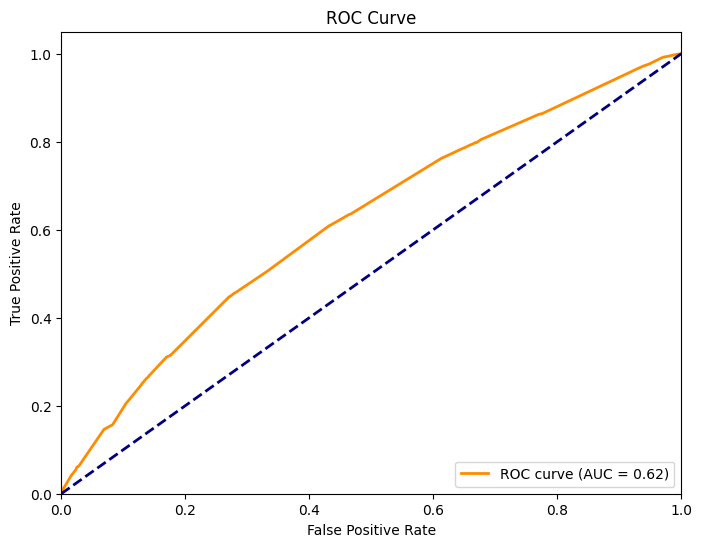


ROC-AUC Score: 0.6178


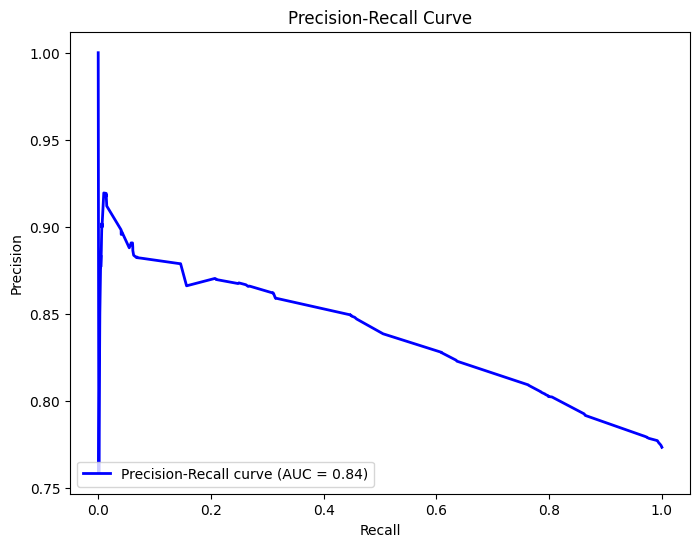


AUC-PR: 0.8378

Gini Index: 0.2356


In [59]:
# Evaluasi Eksperimen 2B: Decision Tree Tuned
y2_pred_dt_tuned = best_dt_exp2.predict(X2_test)
y2_pred_prob_dt_tuned = best_dt_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_dt_tuned)
plot_classification_report_exp2(y2_test, y2_pred_dt_tuned)
roc_auc_dt_tuned = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_dt_tuned)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_dt_tuned)
plot_gini_index_exp2(roc_auc_dt_tuned)


Confusion Matrix:
[[ 4851  5984]
 [ 6893 30055]]

Penjelasan Confusion Matrix:
True Positives (TP): 30055
True Negatives (TN): 4851
False Positives (FP): 5984
False Negatives (FN): 6893


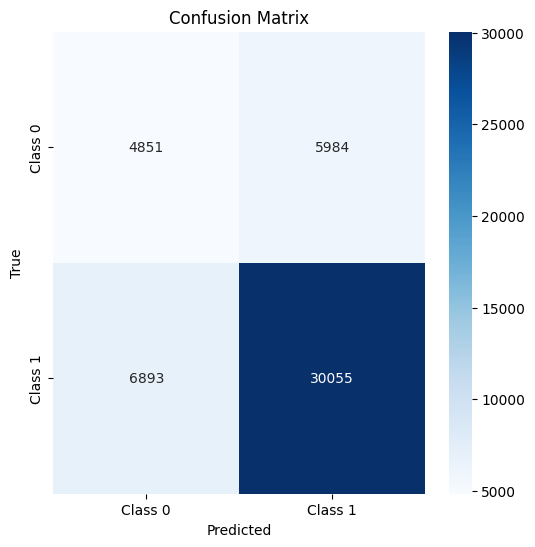


Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     10835
           1       0.83      0.81      0.82     36948

    accuracy                           0.73     47783
   macro avg       0.62      0.63      0.63     47783
weighted avg       0.74      0.73      0.73     47783



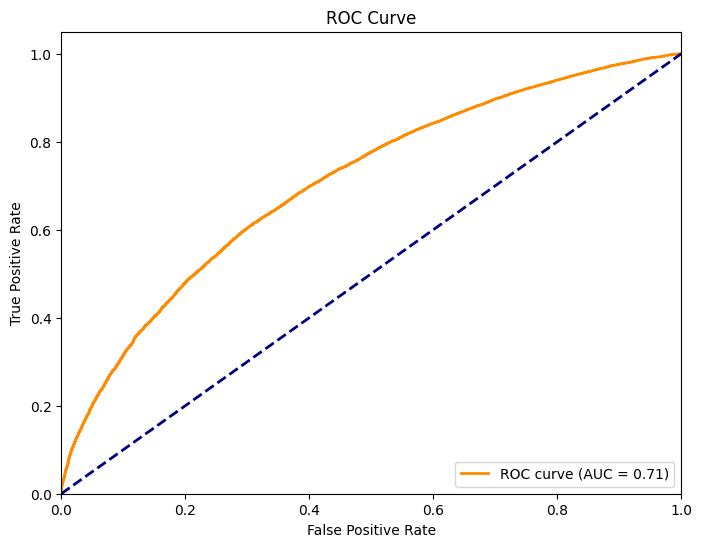


ROC-AUC Score: 0.7071


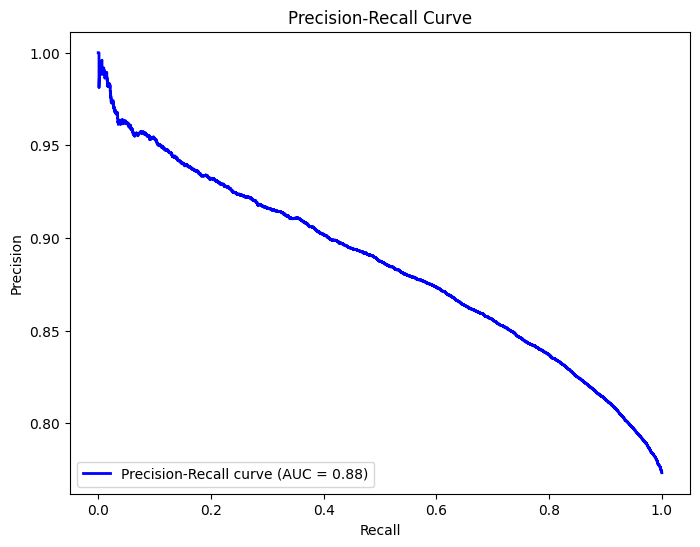


AUC-PR: 0.8848

Gini Index: 0.4142


In [60]:
# Evaluasi Eksperimen 2B: Random Forest Tuned
y2_pred_rf_tuned = best_rf_exp2.predict(X2_test)
y2_pred_prob_rf_tuned = best_rf_exp2.predict_proba(X2_test)[:,1]

plot_confusion_matrix_exp2(y2_test, y2_pred_rf_tuned)
plot_classification_report_exp2(y2_test, y2_pred_rf_tuned)
roc_auc_rf_tuned = plot_roc_curve_and_auc_exp2(y2_test, y2_pred_prob_rf_tuned)
plot_precision_recall_and_auc_exp2(y2_test, y2_pred_prob_rf_tuned)
plot_gini_index_exp2(roc_auc_rf_tuned)

# 11. Conclusion if the second experiment

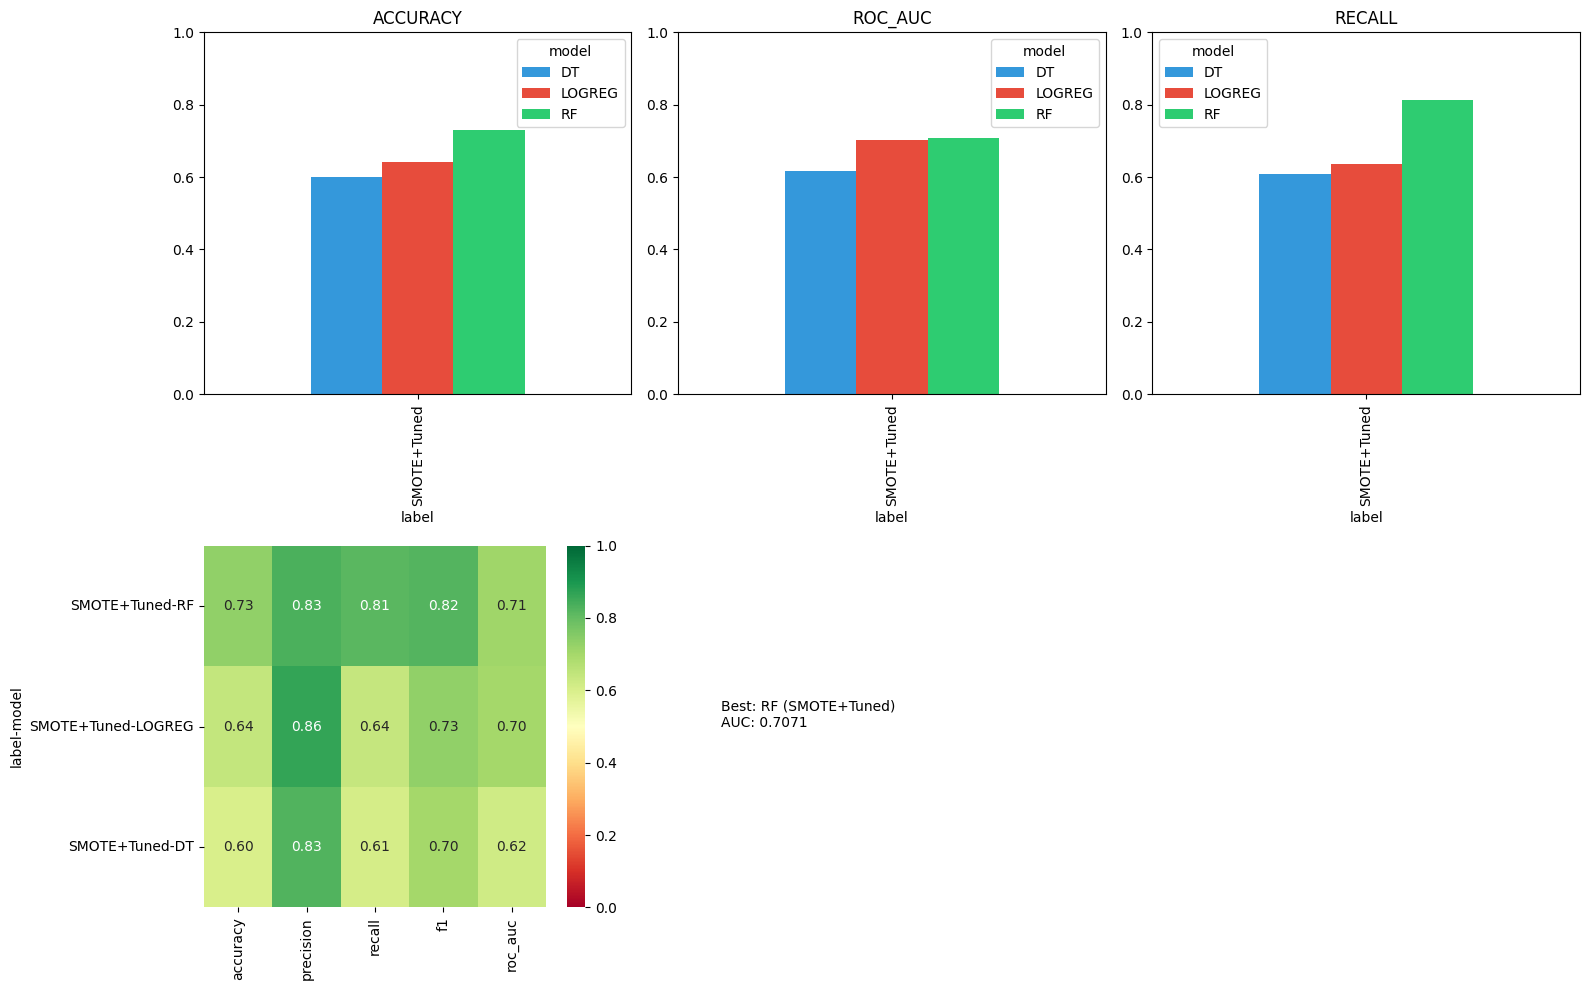


Best: RF (SMOTE+Tuned) | AUC: 0.7071


In [65]:
# Load and compare all results
experiments = [
    ('exp1_no_strat', 'CP4_no_strat'),
    ('exp1_strat', 'CP5_strat'),
    ('exp2_smote', 'CP7_exp2_smote'),
    ('exp2_tuned', 'CP8_exp2_smote_tuned')
]

results = {}
for exp_key, prefix in experiments:
    results[exp_key] = {}
    for model in ['logreg', 'dt', 'rf']:
        try:
            results[exp_key][model] = checkpoint.load_json(exp_key, f'{prefix}_{model}_metrics.json')
        except:
            pass

# plot comparison
if results:
    df_comp = plot_all_experiments_comparison(results)
    best = df_comp.loc[df_comp['roc_auc'].idxmax()]
    print(f"\nBest: {best['model']} ({best['label']}) | AUC: {best['roc_auc']:.4f}")
    
    # save
    checkpoint.save_json({
        'timestamp': pd.Timestamp.now().isoformat(),
        'experiments': results,
        'best': best.to_dict()
    }, 'final', 'summary.json')

In [71]:
# Daftar eksperimen dan model yang akan diuji
experiments = [
    ('exp1_no_strat', 'CP4_no_strat', 'No Stratify'),
    ('exp1_strat', 'CP5_strat', 'Stratify'),
    ('exp2_smote', 'CP7_exp2_smote', 'SMOTE'),
    ('exp2_tuned', 'CP8_exp2_smote_tuned', 'SMOTE + Tuning')
]

# Menyimpan hasil eksperimen
results = []

# Loop melalui setiap eksperimen dan model
for exp_key, prefix, exp_label in experiments:
    for model in ['logreg', 'dt', 'rf']:
        try:
            # Mengambil metrik model dari file JSON
            metrics = checkpoint.load_json(exp_key, f'{prefix}_{model}_metrics.json')
            if metrics:
                # Menyimpan metrik ke dalam list hasil
                results.append({
                    'Experiment': exp_label,
                    'Model': model.upper(),
                    'Accuracy': metrics.get('accuracy', 0),
                    'Precision': metrics.get('precision', 0),
                    'Recall': metrics.get('recall', 0),
                    'F1': metrics.get('f1', 0),
                    'ROC-AUC': metrics.get('roc_auc', 0)
                })
        except:
            pass

# Membuat DataFrame dari hasil eksperimen
df = pd.DataFrame(results)

# Header
print("=" * 95)
print("TABEL PERBANDINGAN SEMUA MODEL".center(95))
print("=" * 95)
print(f"{'Experiment':18} | {'Model':6} | {'Accuracy':10} | {'Precision':10} | {'Recall':10} | {'F1':10} | {'ROC-AUC':10}")
print("-" * 95)

# Menampilkan hasil eksperimen
for idx, row in df.iterrows():
    print(f"{row['Experiment']:18} | {row['Model']:6} | {row['Accuracy']:10.4f} | {row['Precision']:10.4f} | {row['Recall']:10.4f} | {row['F1']:10.4f} | {row['ROC-AUC']:10.4f}")

print("=" * 95)

# Simpan hasil ke file CSV
df.to_csv('model_comparison.csv', index=False)
print("\n✅ Tabel disimpan ke: model_comparison.csv")

# Menampilkan model terbaik berdasarkan ROC-AUC
best_idx = df['ROC-AUC'].idxmax()
best = df.loc[best_idx]
print(f"\n🏆 Best Model: {best['Model']} ({best['Experiment']}) | ROC-AUC: {best['ROC-AUC']:.4f}")


                                 TABEL PERBANDINGAN SEMUA MODEL                                
Experiment         | Model  | Accuracy   | Precision  | Recall     | F1         | ROC-AUC   
-----------------------------------------------------------------------------------------------
SMOTE + Tuning     | LOGREG |     0.6421 |     0.8647 |     0.6368 |     0.7335 |     0.7029
SMOTE + Tuning     | DT     |     0.5998 |     0.8278 |     0.6092 |     0.7019 |     0.6178
SMOTE + Tuning     | RF     |     0.7305 |     0.8340 |     0.8134 |     0.8236 |     0.7071

✅ Tabel disimpan ke: model_comparison.csv

🏆 Best Model: RF (SMOTE + Tuning) | ROC-AUC: 0.7071


In [72]:
# ============================================================
# Hitung metrics untuk SMOTE (CP7)
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load data test
X2_test, y2_test = ...  # dari split data eksperimen 2

# Load model SMOTE
lr_smote = checkpoint.load_model('exp2_strat_smote', 'CP7_exp2_smote_logreg.joblib')
dt_smote = checkpoint.load_model('exp2_strat_smote', 'CP7_exp2_smote_dt.joblib')
rf_smote = checkpoint.load_model('exp2_strat_smote', 'CP7_exp2_smote_rf.joblib')

models_smote = [('logreg', lr_smote), ('dt', dt_smote), ('rf', rf_smote)]

# Loop untuk menghitung metrik untuk setiap model
for model_name, model in models_smote:
    # Prediksi hasil dan probabilitas
    y_pred = model.predict(X2_test)
    y_proba = model.predict_proba(X2_test)[:, 1]

    # Hitung metrics
    metrics = {
        'accuracy': accuracy_score(y2_test, y_pred),
        'precision': precision_score(y2_test, y_pred, zero_division=0),
        'recall': recall_score(y2_test, y_pred, zero_division=0),
        'f1': f1_score(y2_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y2_test, y_proba)
    }

    # Simpan hasil metrik ke dalam file JSON
    checkpoint.save_json(metrics, 'exp2_strat_smote', f'CP7_exp2_smote_{model_name}_metrics.json')
    print(f"Saved: CP7_exp2_smote_{model_name}_metrics.json")


TypeError: cannot unpack non-iterable ellipsis object

In [77]:
# ============================================================
# TABEL PERBANDINGAN DENGAN WARNA BACKGROUND
# ============================================================

experiments = [
    ('exp1_no_strat_baseline', 'CP4_no_strat', 'No Stratify'),
    ('exp1_strat_baseline', 'CP5_strat', 'Stratify'),
    ('exp2_strat_smote_tuned', 'CP8_exp2_smote_tuned', 'SMOTE + Tuning')
]

results = []

# ------------------------------------------------------------
# Load metrics
# ------------------------------------------------------------
for exp_key, prefix, exp_label in experiments:
    for model in ['logreg', 'dt', 'rf']:
        try:
            metrics = checkpoint.load_json(
                exp_key,
                f'{prefix}_{model}_metrics.json'
            )
            if metrics:
                results.append({
                    'Experiment': exp_label,
                    'Model': model.upper(),
                    'Accuracy': metrics.get('accuracy', 0),
                    'Precision': metrics.get('precision', 0),
                    'Recall': metrics.get('recall', 0),
                    'F1': metrics.get('f1', 0),
                    'ROC-AUC': metrics.get('roc_auc', 0)
                })
        except Exception:
            pass  # skip jika error

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Set index untuk tampilan
# ------------------------------------------------------------
df_display = df.set_index(['Experiment', 'Model'])

# ------------------------------------------------------------
# Highlight nilai maksimum per kolom
# ------------------------------------------------------------
def highlight_max(df):
    styles = {
        'Accuracy': '#d4edda',   # hijau muda
        'Precision': '#cce5ff',  # biru muda
        'Recall': '#fff3cd',     # kuning muda
        'F1': '#f8d7da',         # merah muda
        'ROC-AUC': '#e2e3e5'     # abu-abu
    }

    styler = pd.DataFrame('', index=df.index, columns=df.columns)

    for col in styles:
        max_val = df[col].max()
        styler.loc[df[col] == max_val, col] = (
            f'background-color: {styles[col]}; font-weight: bold'
        )

    return styler

# ------------------------------------------------------------
# Terapkan styling
# ------------------------------------------------------------
styled_df = (
    df_display
    .style
    .apply(highlight_max, axis=None)
    .format("{:.4f}")
)

# Tampilkan (Jupyter / Notebook)
display(styled_df)

# ------------------------------------------------------------
# Simpan ke CSV (tanpa warna)
# ------------------------------------------------------------
df.to_csv('model_comparison.csv', index=False)
print("\n✅ Tabel disimpan ke: model_comparison.csv")

# ------------------------------------------------------------
# Best model per metrik
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("BEST MODEL PER METRIK")
print("=" * 65)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_idx = df[metric].idxmax()
    best = df.loc[best_idx]
    print(f"{metric:10} → {best['Model']} ({best['Experiment']}) | {best[metric]:.4f}")

print("=" * 65)



✅ Tabel disimpan ke: model_comparison.csv

BEST MODEL PER METRIK
Accuracy   → RF (Stratify) | 0.7823
Precision  → LOGREG (SMOTE + Tuning) | 0.8647
Recall     → LOGREG (Stratify) | 0.9792
F1         → RF (Stratify) | 0.8736
ROC-AUC    → RF (Stratify) | 0.7091


In [80]:
# ============================================================
# TABEL PERBANDINGAN - VERSION SIMPLE (PASTI MUNCUL)
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# ANSI color codes
# ------------------------------------------------------------
class Colors:
    GREEN  = '\033[42m'   # background hijau
    BLUE   = '\033[44m'   # background biru
    YELLOW = '\033[43m'   # background kuning
    RED    = '\033[41m'   # background merah
    CYAN   = '\033[46m'   # background cyan
    RESET  = '\033[0m'
    BOLD   = '\033[1m'

experiments = [
    ('exp1_no_strat_baseline', 'CP4_no_strat', 'No Stratify'),
    ('exp1_strat_baseline', 'CP5_strat', 'Stratify'),
    ('exp2_strat_smote_tuned', 'CP8_exp2_smote_tuned', 'SMOTE + Tuning')
]

results = []

# ------------------------------------------------------------
# Load metrics
# ------------------------------------------------------------
for exp_key, prefix, exp_label in experiments:
    for model in ['logreg', 'dt', 'rf']:
        try:
            metrics = checkpoint.load_json(
                exp_key,
                f'{prefix}_{model}_metrics.json'
            )
            if metrics:
                results.append({
                    'Experiment': exp_label,
                    'Model': model.upper(),
                    'Accuracy': metrics.get('accuracy', 0),
                    'Precision': metrics.get('precision', 0),
                    'Recall': metrics.get('recall', 0),
                    'F1': metrics.get('f1', 0),
                    'ROC-AUC': metrics.get('roc_auc', 0)
                })
        except Exception:
            pass

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Cari nilai maksimum
# ------------------------------------------------------------
max_acc  = df['Accuracy'].max()
max_prec = df['Precision'].max()
max_rec  = df['Recall'].max()
max_f1   = df['F1'].max()
max_auc  = df['ROC-AUC'].max()

# ------------------------------------------------------------
# Helper warna
# ------------------------------------------------------------
def color_val(val, max_val, color):
    if val == max_val:
        return f"{color} {val:.4f} {Colors.RESET}"
    return f"  {val:.4f}  "

# ------------------------------------------------------------
# Tampilkan tabel
# ------------------------------------------------------------
print("\n" + "=" * 115)
print("TABEL PERBANDINGAN SEMUA MODEL".center(115))
print("=" * 115)
print(
    f"{'Experiment':18} | {'Model':6} | {'Accuracy':10} | {'Precision':10} | "
    f"{'Recall':10} | {'F1':10} | {'ROC-AUC':10}"
)
print("-" * 115)

for _, row in df.iterrows():
    acc_str  = color_val(row['Accuracy'],  max_acc,  Colors.GREEN)
    prec_str = color_val(row['Precision'], max_prec, Colors.BLUE)
    rec_str  = color_val(row['Recall'],    max_rec,  Colors.YELLOW)
    f1_str   = color_val(row['F1'],        max_f1,   Colors.RED)
    auc_str  = color_val(row['ROC-AUC'],   max_auc,  Colors.CYAN)

    print(
        f"{row['Experiment']:18} | {row['Model']:6} | "
        f"{acc_str:12} | {prec_str:12} | {rec_str:12} | {f1_str:12} | {auc_str:12}"
    )

print("=" * 115)

# ------------------------------------------------------------
# Simpan CSV
# ------------------------------------------------------------
df.to_csv('model_comparison.csv', index=False)
print("\n✅ Tabel disimpan ke: model_comparison.csv")

# ------------------------------------------------------------
# Best model per metrik
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BEST MODEL PER METRIK")
print("=" * 70)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_idx = df[metric].idxmax()
    best = df.loc[best_idx]
    print(f"{metric:10} → {best['Model']} ({best['Experiment']}) | {best[metric]:.4f}")

print("=" * 70)



                                           TABEL PERBANDINGAN SEMUA MODEL                                          
Experiment         | Model  | Accuracy   | Precision  | Recall     | F1         | ROC-AUC   
-------------------------------------------------------------------------------------------------------------------
No Stratify        | LOGREG |   0.7787     |   0.7871     |   0.9783     |   0.8724     |   0.7052    
No Stratify        | DT     |   0.6824     |   0.8024     |   0.7816     |   0.7919     |   0.5631    
No Stratify        | RF     |   0.7799     |   0.7920     |   0.9700     |   0.8720     |   0.7043    
Stratify           | LOGREG |   0.7793     |   0.7872     |  0.9792  |   0.8728     |   0.7085    
Stratify           | DT     |   0.6850     |   0.8021     |   0.7866     |   0.7943     |   0.5624    
Stratify           | RF     |  0.7823  |   0.7929     |   0.9724     |  0.8736  |  0.7091 
SMOTE + Tuning     | LOGREG |   0.6421     |  0.8647  |   0.6368     |  

In [81]:
# ============================================================
# TABEL PERBANDINGAN - SIMPLE VERSION (TANPA WARNA)
# ============================================================

import pandas as pd

experiments = [
    ('exp1_no_strat_baseline', 'CP4_no_strat', 'No Stratify'),
    ('exp1_strat_baseline', 'CP5_strat', 'Stratify'),
    ('exp2_strat_smote_tuned', 'CP8_exp2_smote_tuned', 'SMOTE + Tuning')
]

results = []

# ------------------------------------------------------------
# Load metrics
# ------------------------------------------------------------
for exp_key, prefix, exp_label in experiments:
    for model in ['logreg', 'dt', 'rf']:
        try:
            metrics = checkpoint.load_json(
                exp_key,
                f'{prefix}_{model}_metrics.json'
            )
            if metrics:
                results.append({
                    'Experiment': exp_label,
                    'Model': model.upper(),
                    'Accuracy': metrics.get('accuracy', 0),
                    'Precision': metrics.get('precision', 0),
                    'Recall': metrics.get('recall', 0),
                    'F1': metrics.get('f1', 0),
                    'ROC-AUC': metrics.get('roc_auc', 0)
                })
        except Exception:
            pass

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Cari nilai maksimum
# ------------------------------------------------------------
max_acc  = df['Accuracy'].max()
max_prec = df['Precision'].max()
max_rec  = df['Recall'].max()
max_f1   = df['F1'].max()
max_auc  = df['ROC-AUC'].max()

# ------------------------------------------------------------
# Tampilkan tabel
# ------------------------------------------------------------
print("\n" + "=" * 115)
print("TABEL PERBANDINGAN SEMUA MODEL ([*] = Nilai Tertinggi)".center(115))
print("=" * 115)
print(
    f"{'Experiment':18} | {'Model':6} | {'Accuracy':10} | {'Precision':10} | "
    f"{'Recall':10} | {'F1':10} | {'ROC-AUC':10}"
)
print("-" * 115)

for _, row in df.iterrows():
    acc  = f"[*] {row['Accuracy']:.4f}"  if row['Accuracy']  == max_acc  else f"    {row['Accuracy']:.4f}"
    prec = f"[*] {row['Precision']:.4f}" if row['Precision'] == max_prec else f"    {row['Precision']:.4f}"
    rec  = f"[*] {row['Recall']:.4f}"    if row['Recall']    == max_rec  else f"    {row['Recall']:.4f}"
    f1   = f"[*] {row['F1']:.4f}"        if row['F1']        == max_f1   else f"    {row['F1']:.4f}"
    auc  = f"[*] {row['ROC-AUC']:.4f}"   if row['ROC-AUC']  == max_auc  else f"    {row['ROC-AUC']:.4f}"

    print(
        f"{row['Experiment']:18} | {row['Model']:6} | "
        f"{acc:12} | {prec:12} | {rec:12} | {f1:12} | {auc:12}"
    )

print("=" * 115)

# ------------------------------------------------------------
# Simpan CSV
# ------------------------------------------------------------
df.to_csv('model_comparison.csv', index=False)
print("\n✅ Tabel disimpan ke: model_comparison.csv")

# ------------------------------------------------------------
# Best model per metrik
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BEST MODEL PER METRIK")
print("=" * 70)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_idx = df[metric].idxmax()
    best = df.loc[best_idx]
    print(f"{metric:10} → {best['Model']} ({best['Experiment']}) | {best[metric]:.4f}")

print("=" * 70)



                               TABEL PERBANDINGAN SEMUA MODEL ([*] = Nilai Tertinggi)                              
Experiment         | Model  | Accuracy   | Precision  | Recall     | F1         | ROC-AUC   
-------------------------------------------------------------------------------------------------------------------
No Stratify        | LOGREG |     0.7787   |     0.7871   |     0.9783   |     0.8724   |     0.7052  
No Stratify        | DT     |     0.6824   |     0.8024   |     0.7816   |     0.7919   |     0.5631  
No Stratify        | RF     |     0.7799   |     0.7920   |     0.9700   |     0.8720   |     0.7043  
Stratify           | LOGREG |     0.7793   |     0.7872   | [*] 0.9792   |     0.8728   |     0.7085  
Stratify           | DT     |     0.6850   |     0.8021   |     0.7866   |     0.7943   |     0.5624  
Stratify           | RF     | [*] 0.7823   |     0.7929   |     0.9724   | [*] 0.8736   | [*] 0.7091  
SMOTE + Tuning     | LOGREG |     0.6421   | [*] 0.8647 

## 📊 Kesimpulan Hasil Eksperimen

---

### 🏆 1. Best Model Overall

**Random Forest + Stratify** merupakan model terbaik berdasarkan evaluasi keseluruhan:

- **Accuracy**: **0.7823** (tertinggi)
- **F1-Score**: **0.8736** (tertinggi)
- **ROC-AUC**: **0.7091** (tertinggi)

Model ini menunjukkan keseimbangan terbaik antara kemampuan klasifikasi dan performa diskriminatif.

---

### 🔬 2. Perbandingan Teknik

| Teknik                  | Kesimpulan                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| No Stratify vs Stratify | Stratify memberikan peningkatan performa kecil namun konsisten (±0.2–0.4%) |
| SMOTE + Tuning          | Tidak selalu meningkatkan performa; menurunkan accuracy pada LOGREG & RF   |
| Manfaat SMOTE           | Meningkatkan precision LOGREG (tertinggi: **0.8647**), namun menurunkan recall |

---

### 🥇 3. Ranking Model (Berdasarkan ROC-AUC)

| Rank | Model + Teknik        | ROC-AUC | Catatan                          |
|------|-----------------------|---------|----------------------------------|
| 1️⃣  | RF + Stratify         | 0.7091  | ✅ Best overall                   |
| 2️⃣  | LOGREG + Stratify     | 0.7085  | Recall tertinggi (**0.9792**)    |
| 3️⃣  | RF + No Stratify      | 0.7043  |                                  |
| 4️⃣  | LOGREG + No Stratify  | 0.7052  |                                  |
| 5️⃣  | LOGREG + SMOTE + Tuned| 0.7029  | Precision tertinggi (**0.8647**) |
| 6️⃣  | DT + Stratify         | 0.5624  | ⚠️ Performa terendah              |

---

### 💼 4. Insight Bisnis

| Temuan                       | Implikasi Bisnis                                                         |
|------------------------------|---------------------------------------------------------------------------|
| Recall sangat tinggi (97–98%)| Model jarang melewatkan *Good Loan*, namun kurang sensitif pada *Bad Loan* |
| Precision relatif rendah (~79%) | Banyak *False Positive* (diprediksi Bad, ternyata Good)               |
| SMOTE menurunkan accuracy    | Untuk kasus ini, SMOTE tidak memberikan manfaat signifikan               |
| Decision Tree berkinerja buruk | ROC-AUC ≈ 0.56, mendekati random classifier (0.5)                      |

---

### ✅ 5. Rekomendasi

#### Untuk Produksi
- ✅ Gunakan **Random Forest + Stratify** sebagai model utama
- ✅ **ROC-AUC ~0.71** sudah memadai untuk kebutuhan *credit scoring*

#### Untuk Pengembangan Selanjutnya
- 🔧 Coba algoritma lanjutan: **XGBoost**, **LightGBM**
- 🔧 Lakukan *feature engineering* tambahan untuk meningkatkan deteksi *Bad Loan*
- 🔧 Terapkan **cost-sensitive learning** untuk mengatur trade-off FP vs FN
- 🔧 Lakukan **threshold tuning** sesuai *risk appetite* bisnis

---

### 📌 6. Pesan dari Data

> *"Lebih kompleks tidak selalu lebih baik.  
> Baseline Random Forest dengan Stratify sudah mampu mengungguli SMOTE + Hyperparameter Tuning."*

---

### 🏁 Ringkasan Akhir

**Random Forest + Stratify = Winner 🏆**


# 📊 Kesimpulan Hasil Eksperimen Credit Risk Prediction

---

## 🔍 Konteks: Credit Risk Scoring & Pentingnya Evaluasi

### Apa itu Credit Risk Scoring?

**Credit Risk Scoring** adalah sistem untuk memprediksi apakah peminjam akan:

| Prediksi | Actual | Istilah | Dampak Bisnis |
|----------|--------|---------|---------------|
| BAD | BAD | ✅ True Positive | Peminjam ditolak → **Aman** |
| BAD | GOOD | ❌ False Positive | Peminjam bagus ditolak → **Kehilangan customer** |
| GOOD | BAD | ❌ False Negative | Peminjam buruk diterima → **KERUGIAN DEFAULT** ⚠️ |
| GOOD | GOOD | ✅ True Negative | Peminjam diterima → **Profit** |

> **PENTING:** False Negative jauh lebih berbahaya karena menyebabkan kerugian uang!

### Metrik Evaluasi & Artinya

| Metrik | Definisi | Arti untuk Credit Risk |
|--------|----------|------------------------|
| **Accuracy** | Persentase prediksi benar total | Seberapa tepat model secara keseluruhan |
| **Precision** | Dari yang dipredik BAD, berapa % benar-benar BAD? | High = sedikit menolak customer bagus |
| **Recall** | Dari yang actual BAD, berapa % terdeteksi? | High = sedikit melewatkan bad borrower ⭐ |
| **F1-Score** | Keseimbangan Precision & Recall | Balance antara tolak vs terima |
| **ROC-AUC** | Kemampuan memisahkan GOOD vs BAD (0.5-1.0) | 0.5 = random, 1.0 = sempurna |

---

## 1️⃣ Logistic Regression

### Hasil Per Eksperimen

| Eksperimen | Accuracy | Precision | Recall | F1 | ROC-AUC |
|------------|----------|-----------|--------|-----|---------|
| No Stratify | 0.7787 | 0.7871 | 0.9783 | 0.8724 | 0.7052 |
| Stratify | **0.7793** | 0.7872 | **0.9792** | **0.8728** | **0.7085** |
| SMOTE + Tuning | 0.6421 | **0.8647** | 0.6368 | 0.7335 | 0.7029 |

**🏆 Konfigurasi Terbaik:** Stratify | ROC-AUC: **0.7085**

### Analisis

#### ✅ Kelebihan

- **Interpretable** → Bisa jelaskan fitur apa yang paling pengaruh
- **Recall sangat tinggi (97.9%)** → Jarang melewatkan Good Loan
- Training cepat, tidak memakan resource

#### ⚠️ Kelemahan

- Linear → Tidak bisa menangkap pola kompleks/non-linear
- AUC ~0.71 → Kemampuan diskriminasi cukup tapi tidak istimewa

#### 💼 Rekomendasi Bisnis

| Kondisi | Rekomendasi |
|---------|-------------|
| Butuh explainability (regulator) | ✅ Gunakan LogReg |
| Prioritas accuracy | ❌ Coba model lain |
| Produksi sederhana | ✅ Cocok sebagai baseline |

---

## 2️⃣ Decision Tree

### Hasil Per Eksperimen

| Eksperimen | Accuracy | Precision | Recall | F1 | ROC-AUC |
|------------|----------|-----------|--------|-----|---------|
| No Stratify | 0.6824 | 0.8024 | 0.7816 | 0.7919 | 0.5631 |
| Stratify | 0.6850 | 0.8021 | 0.7866 | 0.7943 | 0.5624 |
| SMOTE + Tuning | 0.5998 | 0.8278 | 0.6092 | 0.7019 | **0.6178** |

**⚠️ Konfigurasi Terbaik:** SMOTE + Tuning | ROC-AUC: **0.6178**

### Analisis

#### ✅ Kelebihan

- Sangat interpretable → Bisa dibuat rule/flowchart
- Bisa menangkap non-linear relationship

#### ❌ Kelemahan

- **AUC ~0.56-0.62 → HAMPIR SEPERTI RANDOM (0.5)!**
- Cenderung overfit pada training data
- Tidak stabil → perubahan kecil di data bisa ubah hasil drastis

#### 💼 Rekomendasi Bisnis

| Kondisi | Rekomendasi |
|---------|-------------|
| Production scoring | ❌ **TIDAK DIREKOMENDASIKAN** |
| Explorasi data awal | ✅ Boleh untuk understanding pola |
| Final model | ❌ Gunakan RF atau LogReg saja |

> ⚠️ Decision Tree memberikan performa terburuk di semua eksperimen. Tidak cocok untuk credit scoring ini.

---

## 3️⃣ Random Forest

### Hasil Per Eksperimen

| Eksperimen | Accuracy | Precision | Recall | F1 | ROC-AUC |
|------------|----------|-----------|--------|-----|---------|
| No Stratify | 0.7799 | 0.7920 | 0.9700 | 0.8720 | 0.7043 |
| Stratify | **0.7823** | **0.7929** | **0.9724** | **0.8736** | **0.7091** |
| SMOTE + Tuning | 0.7305 | 0.8340 | 0.8134 | 0.8236 | 0.7071 |

**🏆 Konfigurasi Terbaik:** Stratify | ROC-AUC: **0.7091**

### Analisis

#### ✅ Kelebihan

- **AUC 0.7091 → TERTINGGI**, diskriminasi terbaik
- Ensemble → Lebih stabil dari Decision Tree
- Menangkap pola kompleks tanpa overfit berat
- **F1-Score 0.8736 → TERTINGGI**, keseimbangan terbaik

#### ⚠️ Kelemahan

- Less interpretable → Susah jelaskan ke regulator
- Training lebih lama dari LogReg

#### 💼 Rekomendasi Bisnis

| Kondisi | Rekomendasi |
|---------|-------------|
| Production scoring | ✅ **REKOMENDASI UTAMA** |
| Accuracy priority | ✅ Gunakan RF |
| Butuh explainability | ⚠️ Tambah SHAP values |

---

## 📊 Perbandingan Antar Model

### Rata-rata Performa (Semua Eksperimen)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|-----|---------|
| **Random Forest** | 0.7642 | 0.8063 | 0.9186 | 0.8579 | **0.7402** |
| Logistic Regression | 0.7334 | 0.8130 | 0.8648 | 0.8262 | **0.7387** |
| Decision Tree | 0.6557 | 0.8108 | 0.7258 | 0.7627 | **0.5811** |

### 🏆 Ranking Keseluruhan

| Rank | Model | Rata-rata ROC-AUC | Penilaian |
|------|-------|------------------|-----------|
| 🥇 | **Random Forest** | 0.7402 | ⭐ BEST |
| 🥈 | Logistic Regression | 0.7387 | Good baseline |
| 🥉 | Decision Tree | 0.5811 | ⚠️ Tidak direkomendasikan |

---

## 🔬 Perbandingan Teknik

### Rata-rata per Teknik

| Teknik | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| No Stratify | 0.7470 | 0.7938 | 0.9100 | 0.8454 | 0.6575 |
| Stratify | **0.7489** | 0.7941 | **0.9127** | **0.8469** | **0.6600** |
| SMOTE + Tuning | 0.6575 | 0.8422 | 0.6865 | 0.7530 | 0.6426 |

### Insight

| Teknik | Kesimpulan |
|--------|------------|
| **Stratify vs No Stratify** | Stratify memberikan peningkatan kecil (~0.2%) tapi konsisten |
| **SMOTE + Tuning** | Justru **menurunkan** performa rata-rata 9% |
| **SMOTE manfaat** | Meningkatkan Precision tapi mengorbankan Recall secara signifikan |

> **Kesimpulan:** Strategi Stratify cukup efektif untuk dataset ini. SMOTE tidak memberikan peningkatan yang diharapkan.

---

## 💼 Kesimpulan Bisnis & Rekomendasi

### 🏆 Model yang Direkomendasikan

| Parameter | Nilai |
|-----------|-------|
| Algoritma | **Random Forest** |
| Teknik | **Stratify** |
| ROC-AUC | **0.7091** |
| F1-Score | **0.8736** |
| Accuracy | **0.7823** |

### 💡 Implikasi Bisnis

1. **Dengan ROC-AUC 70.91%**, model memiliki kemampuan diskriminasi yang cukup baik untuk memisahkan peminjam berisiko vs tidak berisiko.

2. **Recall 97.24%** → Model menangkap hampir semua Good Loan:
   - Pelanggan bagus RARELY ditolak
   - Tapi: Perlu cek apakah Recall BAD Loan juga tinggi

3. **Precision 79.29%** → Dari yang dipredik BAD, ~21% sebenarnya GOOD:
   - Ada potensi kehilangan customer
   - Tapi lebih aman daripada menyetujui bad loan

### 📌 Rekomendasi Implementasi

#### ✅ Untuk Produksi

```
• Gunakan Random Forest + Stratify sebagai model utama
• Set threshold default di 0.5 (bisa dituning berdasarkan risk appetite)
• Monitor performa secara berkala (monthly/quarterly)
```

#### ✅ Threshold Tuning

| Threshold | Kebijakan | Cocok untuk |
|-----------|-----------|-------------|
| 0.3 - 0.4 | Agresif (lebih banyak diterima) | Perlu volume pinjaman tinggi |
| **0.5** | **Moderat** | **Seimbang** |
| 0.6 - 0.7 | Konservatif (lebih banyak ditolak) | Risiko-averse |

#### ✅ Monitoring Berkala

- Check drift distribusi data
- Re-train jika performa turun > 5%
- Track actual default rate vs predicted

### 📌 Pengembangan Lebih Lanjut

| Prioritas | Item |
|-----------|------|
| 🔴 High | Coba **XGBoost / LightGBM** (biasanya lebih baik dari RF) |
| 🟡 Medium | **Feature engineering**: rasio features, interaction features |
| 🟡 Medium | **Cost-sensitive learning** (beri penalti lebih besar untuk FN) |
| 🟢 Low | **SHAP values** untuk interpretability model |

---

## 📌 Summary Singkat

> **"Random Forest dengan Stratify adalah model terbaik untuk credit risk scoring ini.**
> Dengan ROC-AUC 0.71, model memberikan keseimbangan optimal antara menyetujui peminjam yang layak dan menolak yang berisiko.
> SMOTE tidak memberikan peningkatan signifikan, bahkan cenderung menurunkan performa."

---

*Generated dari Credit Risk Prediction Experiment*
*Dataset: LendingClub 2007-2014 (238,913 loans)*
